# Explainable Artificial Intelligence for Customer Churn Prediction
## A Data-Driven and Ethical Machine Learning Study

**MSc Data Science Dissertation — COM 752**

---

This notebook implements the complete analytical pipeline for predicting customer churn in banking using machine learning, with a focus on Explainable AI (XAI) techniques. The analysis progresses through:

1. **Exploratory Data Analysis (EDA)** — understanding the dataset
2. **Data Preprocessing** — preparing data for modelling
3. **Model Training** — Logistic Regression, Random Forest, SVM, XGBoost, LightGBM
4. **Model Evaluation** — comprehensive performance comparison
5. **Explainable AI** — SHAP-based model interpretation

All figures are saved at 300 DPI in the `figures/` directory for direct inclusion in the dissertation.

---
## 1. Library Imports

The following libraries are used throughout the analysis:
- **pandas / numpy**: Data manipulation and numerical computation
- **matplotlib / seaborn**: Statistical visualisation
- **scikit-learn**: Machine learning models and evaluation metrics
- **xgboost / lightgbm**: Gradient boosting frameworks
- **shap**: SHapley Additive exPlanations for model interpretability

*Dissertation Note (Methodology):* List all libraries with version numbers in your Methodology chapter under "Software and Tools".

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

FIGURE_DIR = 'figures'
os.makedirs(FIGURE_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")
print(f"Figures will be saved to: {os.path.abspath(FIGURE_DIR)}")

All libraries imported successfully.
Figures will be saved to: /workspace/figures


---
## 2. Data Loading

The dataset is a synthetic bank customer churn dataset containing 10,000 records. Each row represents a bank customer, and the target variable `churn` indicates whether the customer has left the bank (1) or not (0).

*Dissertation Note (Methodology):* Describe the dataset as "a publicly available synthetic dataset comprising 10,000 customer records with 12 attributes". Emphasise that the data is synthetic and fully anonymised, which eliminates ethical concerns regarding personal data.

In [2]:
df = pd.read_csv('Bank Customer Churn Prediction.csv')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
df.head(10)

Dataset shape: 10000 rows × 12 columns

Column names:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


---
## 3. Exploratory Data Analysis (EDA)

EDA is essential for understanding the structure, quality, and distribution of the data before modelling. This section examines summary statistics, missing values, class balance, and key feature distributions.

*Dissertation Note (Methodology/Results):* Present EDA findings in the Results chapter with references to figures. Justify preprocessing decisions based on EDA observations.

### 3.1 Summary Statistics

Descriptive statistics provide an overview of central tendency, dispersion, and the range of each numerical feature.

In [3]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"\nShape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
df.describe().round(2)

DATASET INFORMATION

Shape: (10000, 12)

Data Types:
customer_id           int64
credit_score          int64
country                 str
gender                  str
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Memory Usage: 1845.0 KB

DESCRIPTIVE STATISTICS


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [4]:
print("="*60)
print("CATEGORICAL VARIABLE SUMMARY")
print("="*60)
for col in ['country', 'gender']:
    print(f"\n{col.upper()} Distribution:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

CATEGORICAL VARIABLE SUMMARY

COUNTRY Distribution:
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Unique values: 3

GENDER Distribution:
gender
Male      5457
Female    4543
Name: count, dtype: int64
Unique values: 2


### 3.2 Missing Values Check

Identifying missing data is critical as it can bias model training and evaluation.

In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})

print("="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

if missing.sum() == 0:
    print("\n✓ No missing values detected. The dataset is complete.")
else:
    print("\n⚠ Missing values found. Imputation strategy required.")

MISSING VALUES ANALYSIS
                  Missing Count  Percentage (%)
customer_id                   0             0.0
credit_score                  0             0.0
country                       0             0.0
gender                        0             0.0
age                           0             0.0
tenure                        0             0.0
balance                       0             0.0
products_number               0             0.0
credit_card                   0             0.0
active_member                 0             0.0
estimated_salary              0             0.0
churn                         0             0.0

Total missing values: 0

✓ No missing values detected. The dataset is complete.


### 3.3 Target Variable Distribution (Churn)

Examining class balance is essential because imbalanced datasets can lead to biased models that favour the majority class.

*Dissertation Note (Results):* Report the exact class distribution and discuss implications for model training (e.g., potential need for class weighting or resampling).

CHURN DISTRIBUTION

Retained (0): 7963 (79.6%)
Churned  (1): 2037 (20.4%)
Imbalance Ratio: 3.91:1


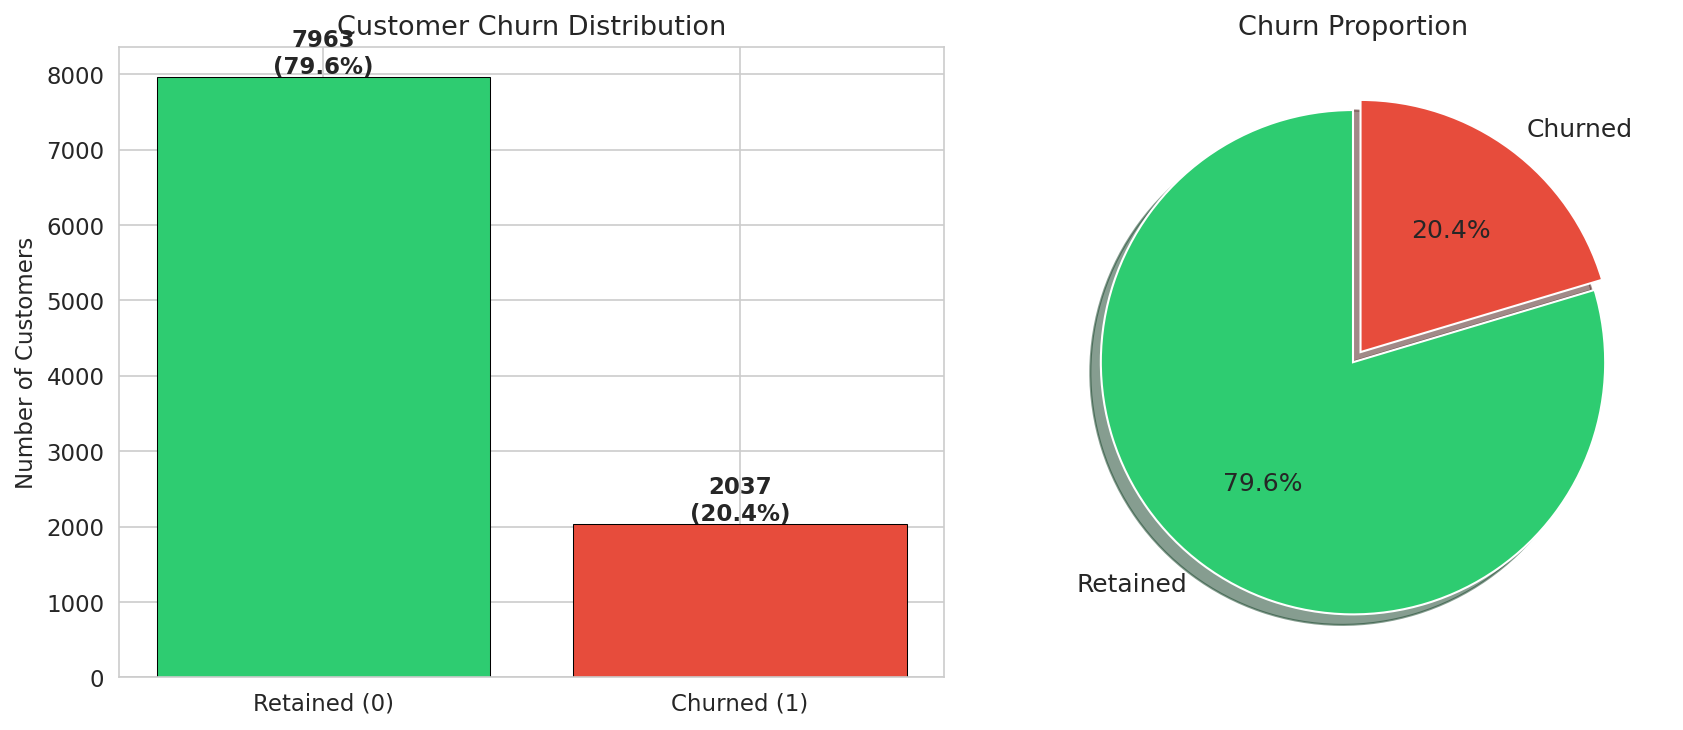


[Figure saved: fig1_churn_distribution.png]


In [6]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print("="*60)
print("CHURN DISTRIBUTION")
print("="*60)
print(f"\nRetained (0): {churn_counts[0]} ({churn_pct[0]:.1f}%)")
print(f"Churned  (1): {churn_counts[1]} ({churn_pct[1]:.1f}%)")
print(f"Imbalance Ratio: {churn_counts[0]/churn_counts[1]:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Customer Churn Distribution')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v}\n({churn_pct.values[i]:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12}, shadow=True)
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig1_churn_distribution.png', bbox_inches='tight')
plt.show()
print("\n[Figure saved: fig1_churn_distribution.png]")

### 3.4 Key Feature Distributions by Churn Status

Visualising feature distributions stratified by churn status helps identify potential predictors and informs feature engineering decisions.

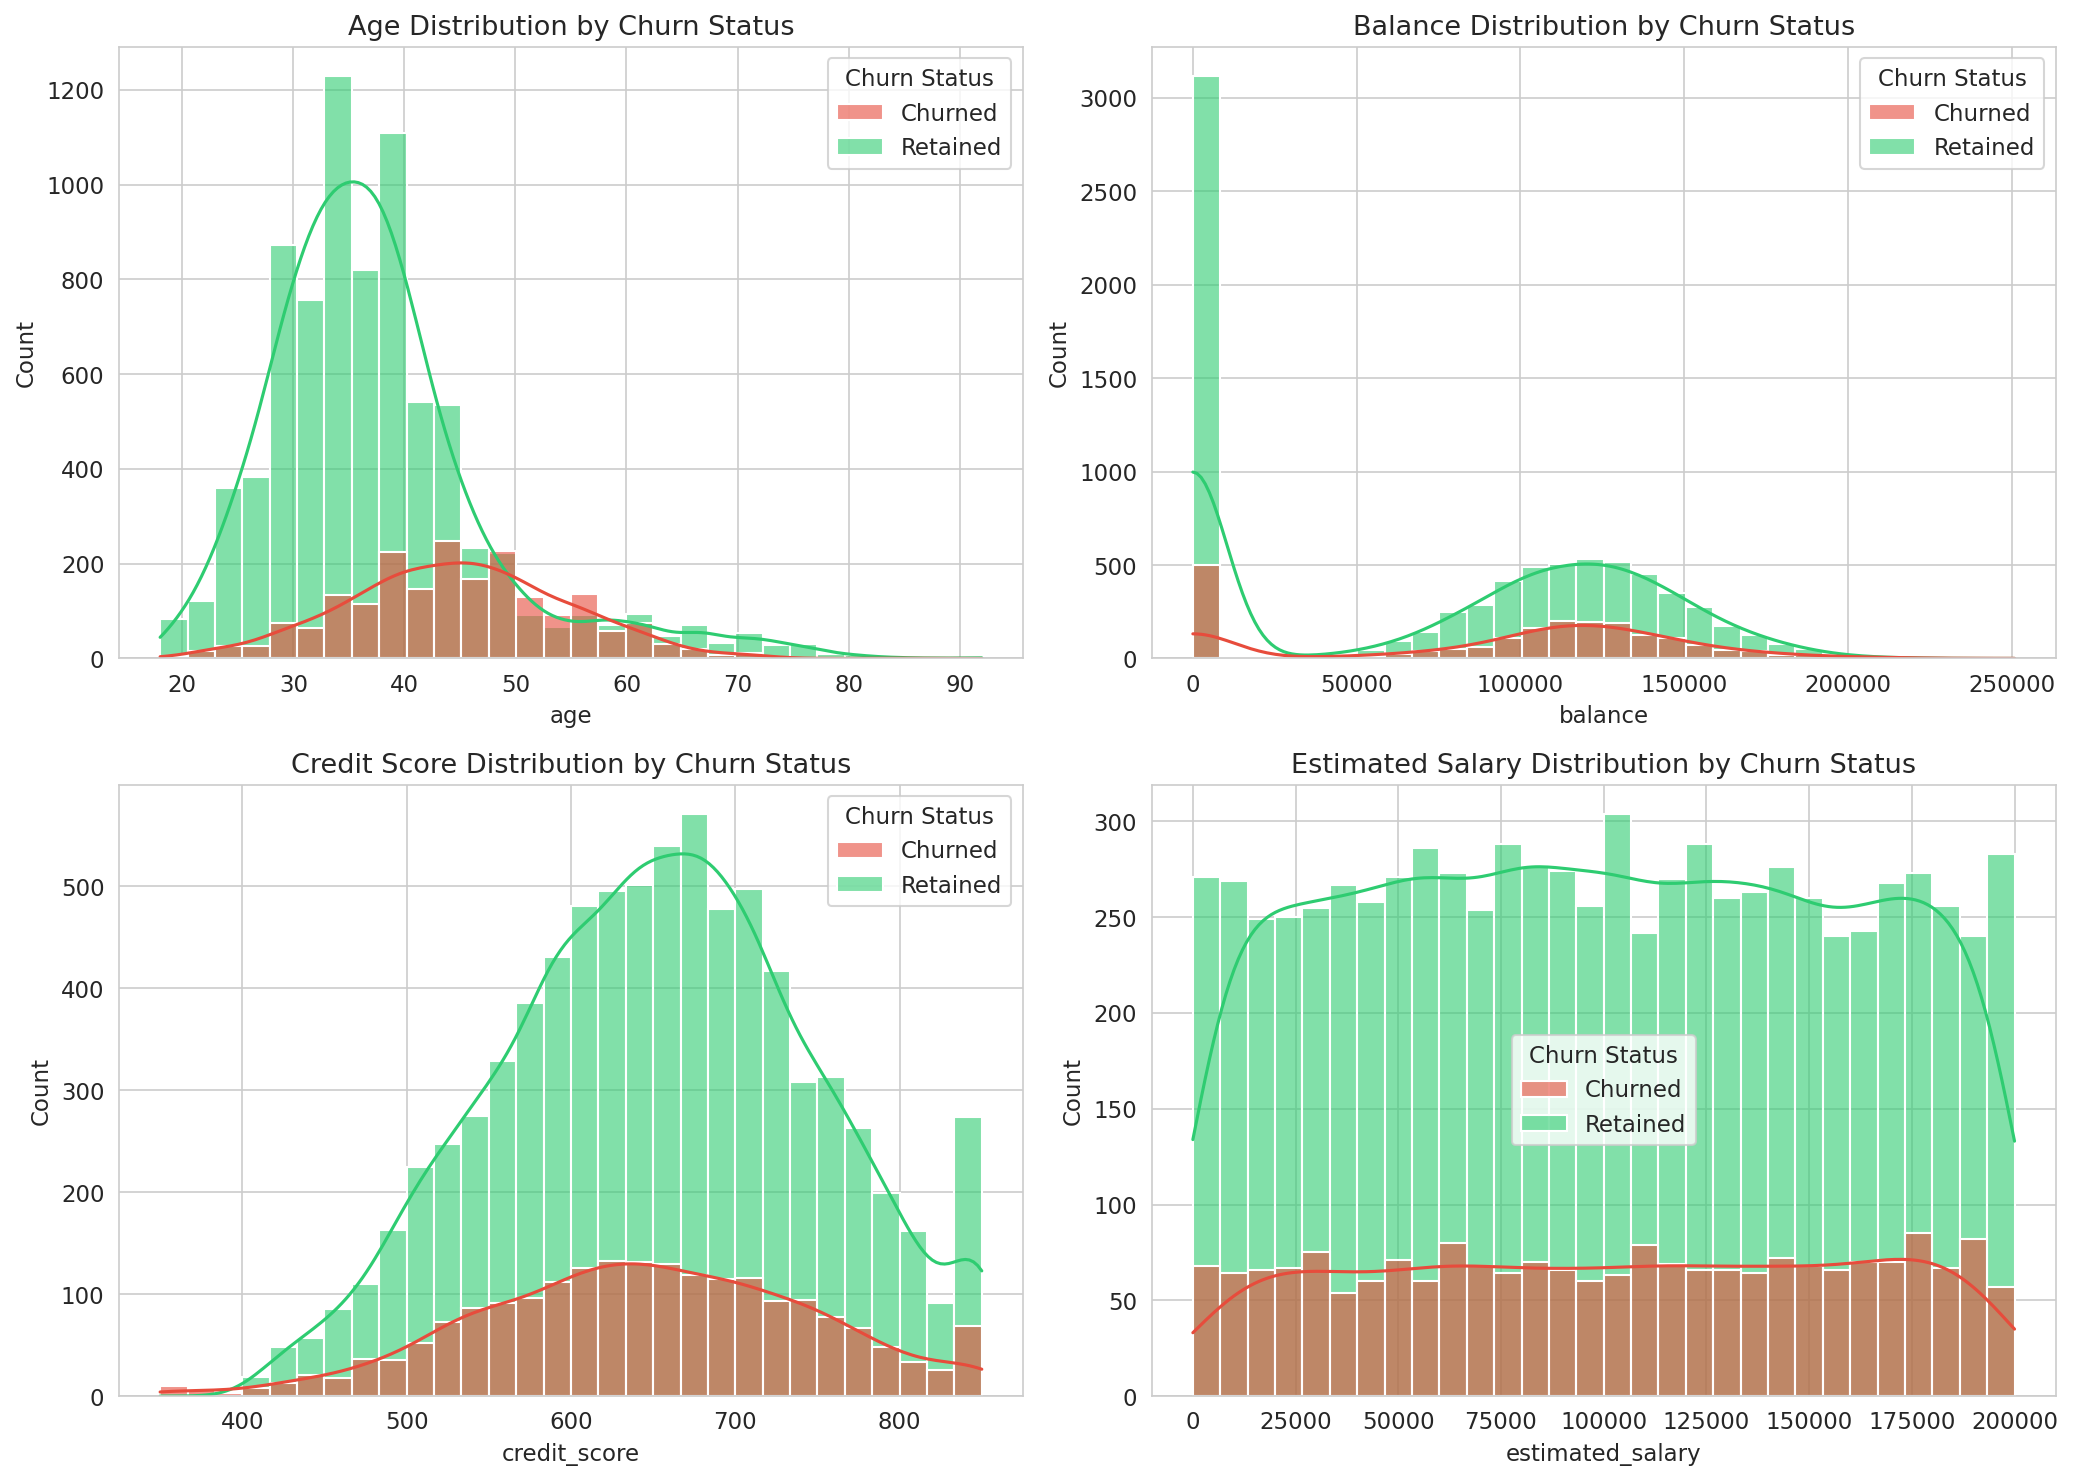

[Figure saved: fig2_feature_distributions.png]


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_hist = df.copy()
df_hist['Churn Status'] = df_hist['churn'].map({0: 'Retained', 1: 'Churned'})
palette_churn = {'Retained': '#2ecc71', 'Churned': '#e74c3c'}

sns.histplot(data=df_hist, x='age', hue='Churn Status', kde=True, bins=30,
             palette=palette_churn, ax=axes[0, 0], alpha=0.6)
axes[0, 0].set_title('Age Distribution by Churn Status')

sns.histplot(data=df_hist, x='balance', hue='Churn Status', kde=True, bins=30,
             palette=palette_churn, ax=axes[0, 1], alpha=0.6)
axes[0, 1].set_title('Balance Distribution by Churn Status')

sns.histplot(data=df_hist, x='credit_score', hue='Churn Status', kde=True, bins=30,
             palette=palette_churn, ax=axes[1, 0], alpha=0.6)
axes[1, 0].set_title('Credit Score Distribution by Churn Status')

sns.histplot(data=df_hist, x='estimated_salary', hue='Churn Status', kde=True, bins=30,
             palette=palette_churn, ax=axes[1, 1], alpha=0.6)
axes[1, 1].set_title('Estimated Salary Distribution by Churn Status')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig2_feature_distributions.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig2_feature_distributions.png]")

### 3.5 Categorical Feature Analysis

Examining churn rates across categorical features (geography, gender) reveals group-level differences that may reflect important patterns.

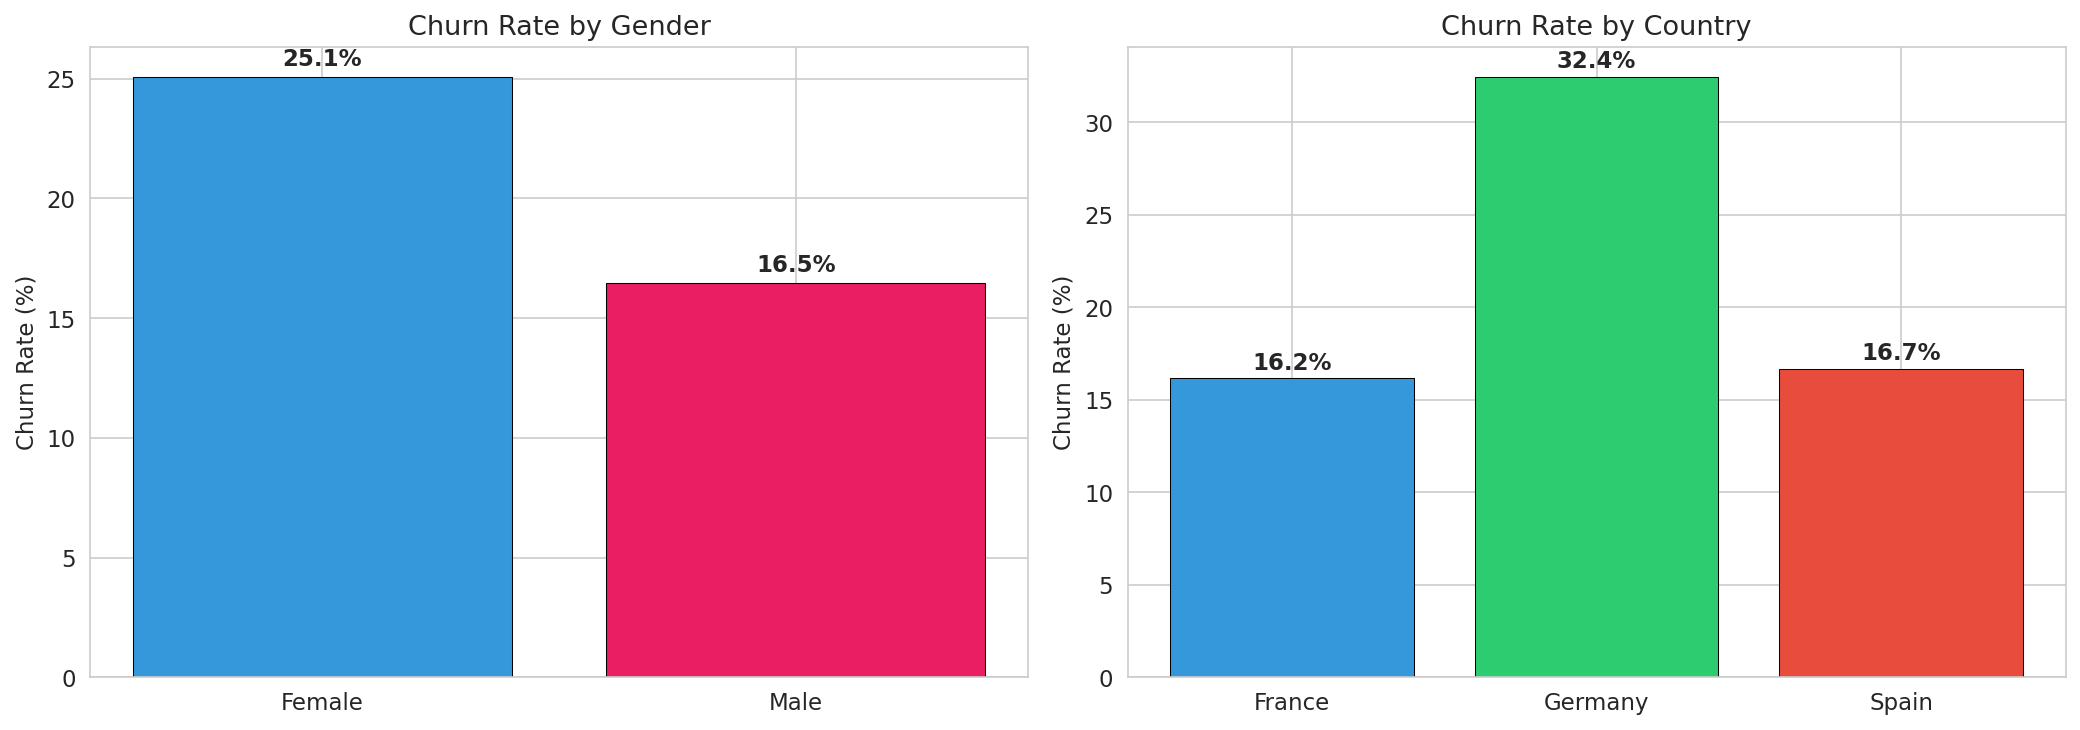

[Figure saved: fig3_categorical_churn_rates.png]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_churn = df.groupby('gender')['churn'].mean() * 100
bars1 = axes[0].bar(gender_churn.index, gender_churn.values, color=['#3498db', '#e91e63'],
                     edgecolor='black', linewidth=0.5)
axes[0].set_title('Churn Rate by Gender')
axes[0].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars1, gender_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

country_churn = df.groupby('country')['churn'].mean() * 100
bars2 = axes[1].bar(country_churn.index, country_churn.values,
                     color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Churn Rate by Country')
axes[1].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars2, country_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig3_categorical_churn_rates.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig3_categorical_churn_rates.png]")

### 3.6 Correlation Heatmap

A correlation matrix reveals linear relationships between numerical features and the target variable, guiding feature selection.

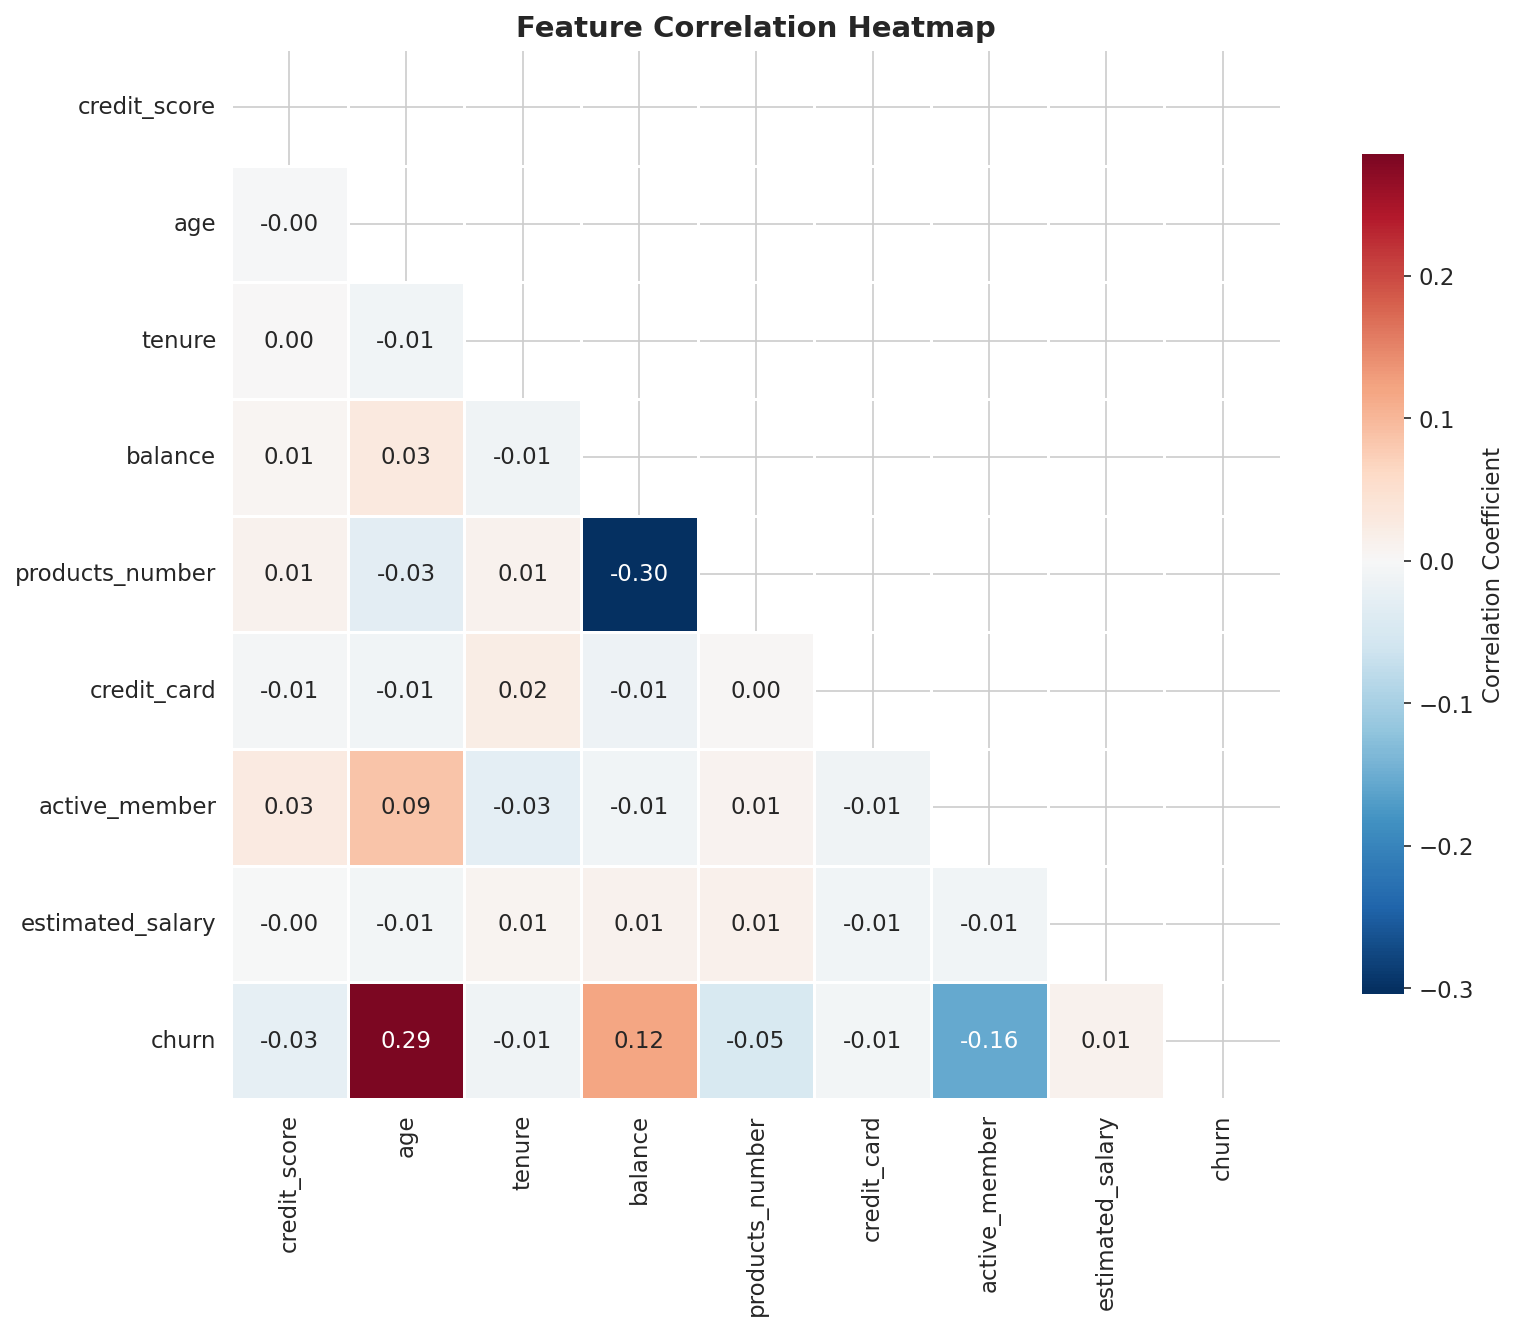


Correlations with Churn (sorted by absolute value):
  age                      : +0.285 (positive)
  active_member            : -0.156 (negative)
  balance                  : +0.119 (positive)
  products_number          : -0.048 (negative)
  credit_score             : -0.027 (negative)
  tenure                   : -0.014 (negative)
  estimated_salary         : +0.012 (positive)
  credit_card              : -0.007 (negative)

[Figure saved: fig4_correlation_heatmap.png]


In [9]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'customer_id' in numerical_cols:
    numerical_cols.remove('customer_id')

corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\nCorrelations with Churn (sorted by absolute value):")
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
for feat, val in churn_corr.items():
    direction = "positive" if corr_matrix.loc[feat, 'churn'] > 0 else "negative"
    print(f"  {feat:25s}: {corr_matrix.loc[feat, 'churn']:+.3f} ({direction})")

print("\n[Figure saved: fig4_correlation_heatmap.png]")

### 3.7 Box Plots — Outlier Detection

Box plots highlight the spread and potential outliers in key numerical features, stratified by churn status.

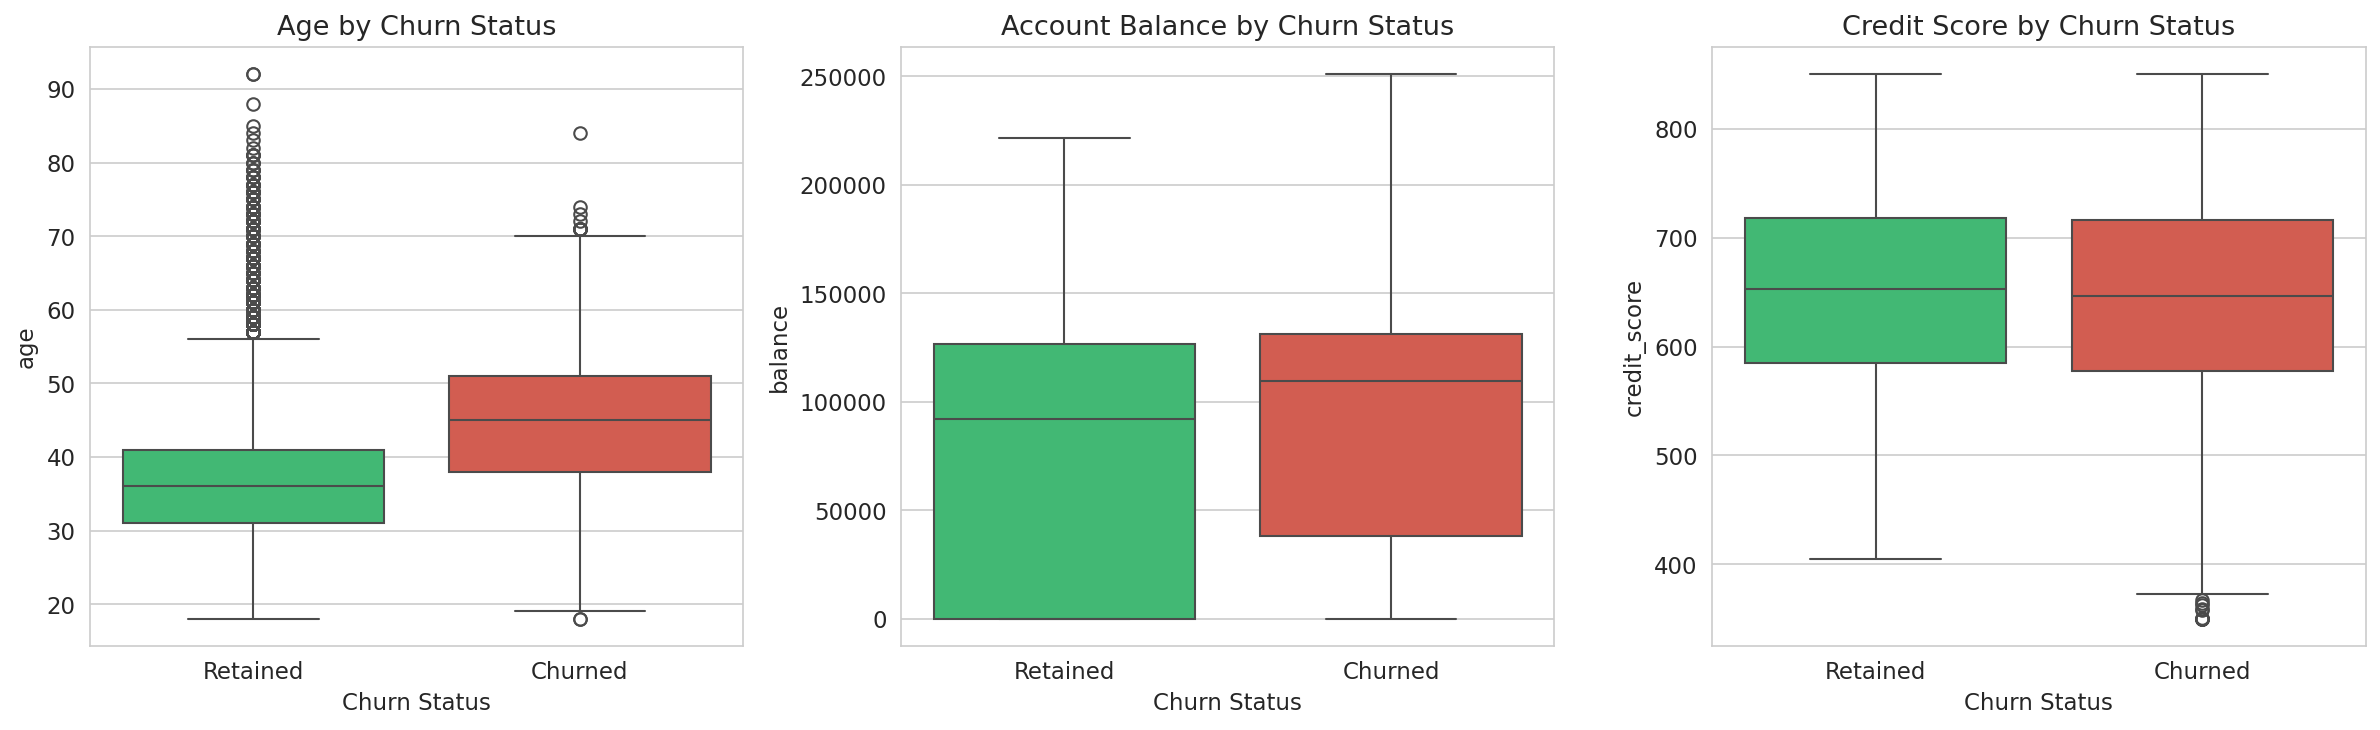

[Figure saved: fig5_boxplots.png]


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_plot = df.copy()
df_plot['churn_label'] = df_plot['churn'].map({0: 'Retained', 1: 'Churned'})

for ax, col, title in zip(axes, ['age', 'balance', 'credit_score'],
                           ['Age', 'Account Balance', 'Credit Score']):
    sns.boxplot(data=df_plot, x='churn_label', y=col,
                palette={'Retained': '#2ecc71', 'Churned': '#e74c3c'},
                order=['Retained', 'Churned'], ax=ax)
    ax.set_xlabel('Churn Status')
    ax.set_title(f'{title} by Churn Status')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig5_boxplots.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig5_boxplots.png]")

### 3.8 Number of Products vs Churn

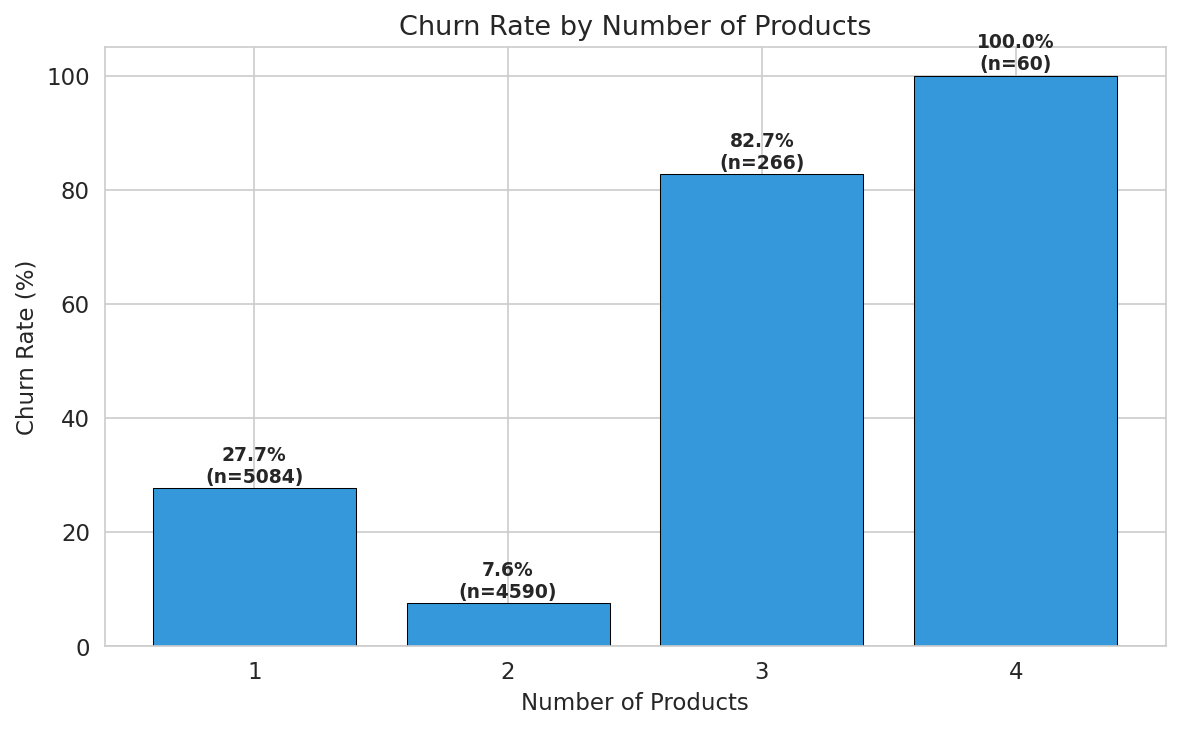

[Figure saved: fig6_products_churn.png]


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
product_churn = df.groupby('products_number')['churn'].agg(['mean', 'count']).reset_index()
product_churn.columns = ['products_number', 'churn_rate', 'count']
product_churn['churn_rate'] *= 100

bars = ax.bar(product_churn['products_number'], product_churn['churn_rate'],
              color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Products')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Number of Products')
ax.set_xticks(product_churn['products_number'])

for bar, rate, count in zip(bars, product_churn['churn_rate'], product_churn['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate:.1f}%\n(n={count})', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig6_products_churn.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig6_products_churn.png]")

---
## 4. Data Preprocessing

Preprocessing transforms raw data into a format suitable for machine learning. Steps include:
1. Dropping irrelevant identifier columns
2. Encoding categorical variables (one-hot encoding)
3. Scaling numerical features for algorithms sensitive to feature magnitude

*Dissertation Note (Methodology):* Justify each preprocessing step. Explain that StandardScaler was applied to ensure features have zero mean and unit variance, which is particularly important for Logistic Regression and SVM.

In [12]:
print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# 4.1 Drop irrelevant columns
df_processed = df.drop(columns=['customer_id'])
print(f"\n[Step 1] Dropped 'customer_id' — identifiers carry no predictive value.")
print(f"  Remaining columns: {df_processed.shape[1]}")

# 4.2 One-hot encode categorical variables
df_processed = pd.get_dummies(df_processed, columns=['country', 'gender'], drop_first=True)
print(f"\n[Step 2] Applied one-hot encoding to 'country' and 'gender'.")
print(f"  New columns: {list(df_processed.columns)}")
print(f"  Shape after encoding: {df_processed.shape}")

# 4.3 Separate features and target
X = df_processed.drop(columns=['churn'])
y = df_processed['churn']

print(f"\n[Step 3] Separated features (X) and target (y).")
print(f"  Features shape: {X.shape}")
print(f"  Target distribution:\n{y.value_counts()}")

# 4.4 Feature scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"\n[Step 4] Applied StandardScaler to all features.")
print(f"  Feature means (should be ~0): {X_scaled.mean().mean():.6f}")
print(f"  Feature stds  (should be ~1): {X_scaled.std().mean():.6f}")

print(f"\n{'='*60}")
print("PREPROCESSING COMPLETE")
print(f"{'='*60}")
print(f"Final feature set: {X_scaled.shape[1]} features × {X_scaled.shape[0]} samples")

DATA PREPROCESSING

[Step 1] Dropped 'customer_id' — identifiers carry no predictive value.
  Remaining columns: 11

[Step 2] Applied one-hot encoding to 'country' and 'gender'.
  New columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn', 'country_Germany', 'country_Spain', 'gender_Male']
  Shape after encoding: (10000, 12)

[Step 3] Separated features (X) and target (y).
  Features shape: (10000, 11)
  Target distribution:
churn
0    7963
1    2037
Name: count, dtype: int64

[Step 4] Applied StandardScaler to all features.
  Feature means (should be ~0): -0.000000
  Feature stds  (should be ~1): 1.000050

PREPROCESSING COMPLETE
Final feature set: 11 features × 10000 samples


---
## 5. Train-Test Split

The data is split into training (80%) and testing (20%) sets using stratified sampling to preserve the class distribution in both subsets.

*Dissertation Note (Methodology):* State the split ratio, the stratification strategy, and the random seed for reproducibility.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)
print(f"\nTraining set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTraining target distribution:")
print(f"  Retained: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Churned:  {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"\nTesting target distribution:")
print(f"  Retained: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Churned:  {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

TRAIN-TEST SPLIT

Training set: 8000 samples (80%)
Testing set:  2000 samples (20%)

Training target distribution:
  Retained: 6370 (79.6%)
  Churned:  1630 (20.4%)

Testing target distribution:
  Retained: 1593 (79.7%)
  Churned:  407 (20.3%)


---
## 6. Model Training

Five classification models are trained and evaluated:
1. **Logistic Regression** — a linear baseline model
2. **Random Forest** — an ensemble of decision trees
3. **Support Vector Machine (SVM)** — finds optimal separating hyperplanes
4. **XGBoost** — gradient boosted trees with regularisation
5. **LightGBM** — efficient gradient boosting with histogram-based learning

*Dissertation Note (Methodology):* For each model, describe its algorithmic basis, justify its inclusion, and state hyperparameter choices. Discuss why ensemble and boosting methods are expected to outperform linear models on this task.

In [14]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf', C=1.0, gamma='scale', probability=True,
        random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0,
        use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=RANDOM_STATE, verbose=-1
    )
}

trained_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("="*60)
print("MODEL TRAINING WITH 5-FOLD CROSS-VALIDATION")
print("="*60)

for name, model in models.items():
    print(f"\nTraining {name}...", end=" ")
    model.fit(X_train, y_train)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    trained_models[name] = model
    print(f"Done. CV F1: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

print(f"\n{'='*60}")
print("ALL MODELS TRAINED SUCCESSFULLY")
print(f"{'='*60}")

MODEL TRAINING WITH 5-FOLD CROSS-VALIDATION

Training Logistic Regression... Done. CV F1: 0.4884 (±0.0204)

Training Random Forest... 

Done. CV F1: 0.6188 (±0.0221)

Training SVM... 

Done. CV F1: 0.5886 (±0.0242)

Training XGBoost... 

Done. CV F1: 0.5967 (±0.0175)

Training LightGBM... 

Done. CV F1: 0.6113 (±0.0182)

ALL MODELS TRAINED SUCCESSFULLY


---
## 7. Model Evaluation

Each model is evaluated on the held-out test set using multiple metrics:
- **Accuracy** — overall correctness
- **Precision** — proportion of predicted positives that are truly positive
- **Recall (Sensitivity)** — proportion of actual positives correctly identified
- **F1 Score** — harmonic mean of precision and recall
- **AUC-ROC** — area under the Receiver Operating Characteristic curve

*Dissertation Note (Results):* Present results in a comparison table and discuss trade-offs between metrics. For churn prediction, recall is particularly important because failing to identify a churning customer is costlier than a false alarm.

### 7.1 Performance Metrics Comparison

In [15]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    }

results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('F1 Score', ascending=False)

print("="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(results_df.to_string())

results_df.to_csv('outputs/model_comparison.csv')
print("\n[Table saved: outputs/model_comparison.csv]")

print(f"\nBest model by F1 Score: {results_df.index[0]} ({results_df.iloc[0]['F1 Score']:.4f})")
print(f"Best model by AUC-ROC: {results_df.sort_values('AUC-ROC', ascending=False).index[0]} "
      f"({results_df.sort_values('AUC-ROC', ascending=False).iloc[0]['AUC-ROC']:.4f})")

MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1 Score  AUC-ROC
Random Forest          0.8375     0.5915  0.6511    0.6199   0.8639
XGBoost                0.8225     0.5524  0.6732    0.6069   0.8469
LightGBM               0.8150     0.5361  0.6757    0.5978   0.8501
SVM                    0.7865     0.4838  0.7346    0.5834   0.8496
Logistic Regression    0.7135     0.3872  0.7002    0.4987   0.7771

[Table saved: outputs/model_comparison.csv]

Best model by F1 Score: Random Forest (0.6199)
Best model by AUC-ROC: Random Forest (0.8639)


### 7.2 Performance Metrics Visualisation

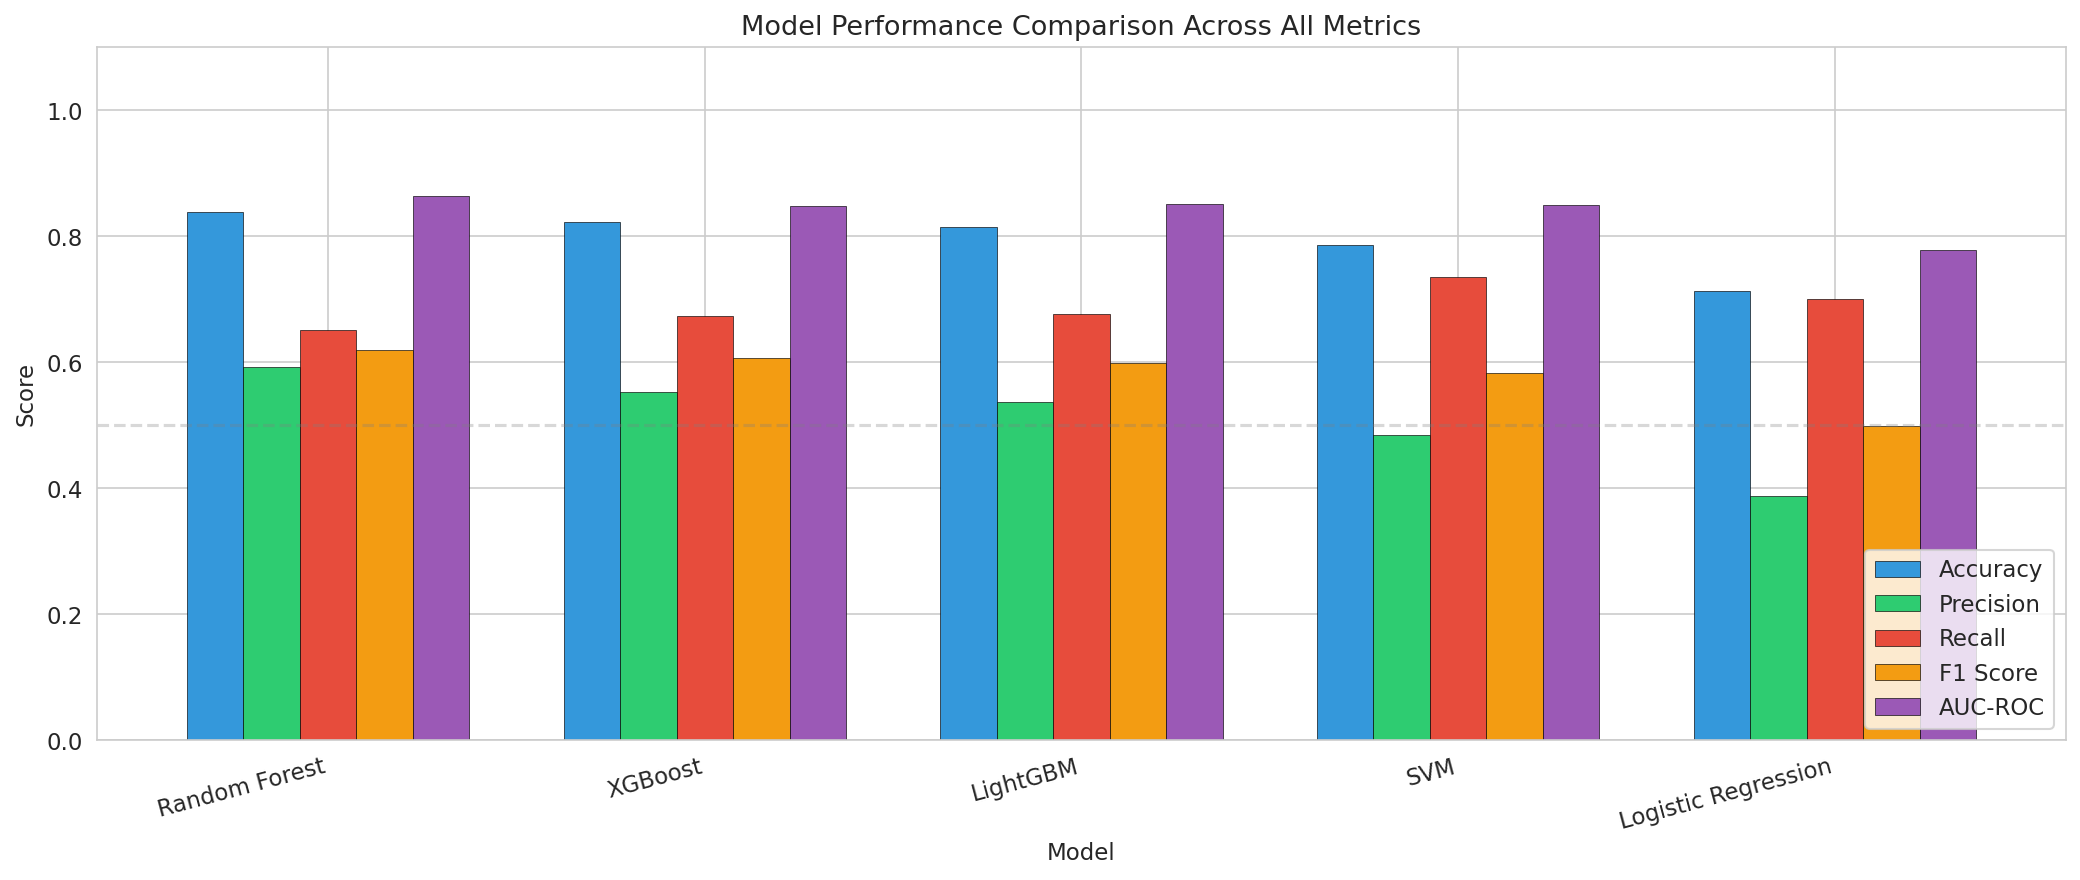

[Figure saved: fig7_model_comparison.png]


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_df.index))
width = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric,
                  color=color, edgecolor='black', linewidth=0.3)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison Across All Metrics')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig7_model_comparison.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig7_model_comparison.png]")

### 7.3 Confusion Matrices

Confusion matrices show the breakdown of true positives, true negatives, false positives, and false negatives for each model.

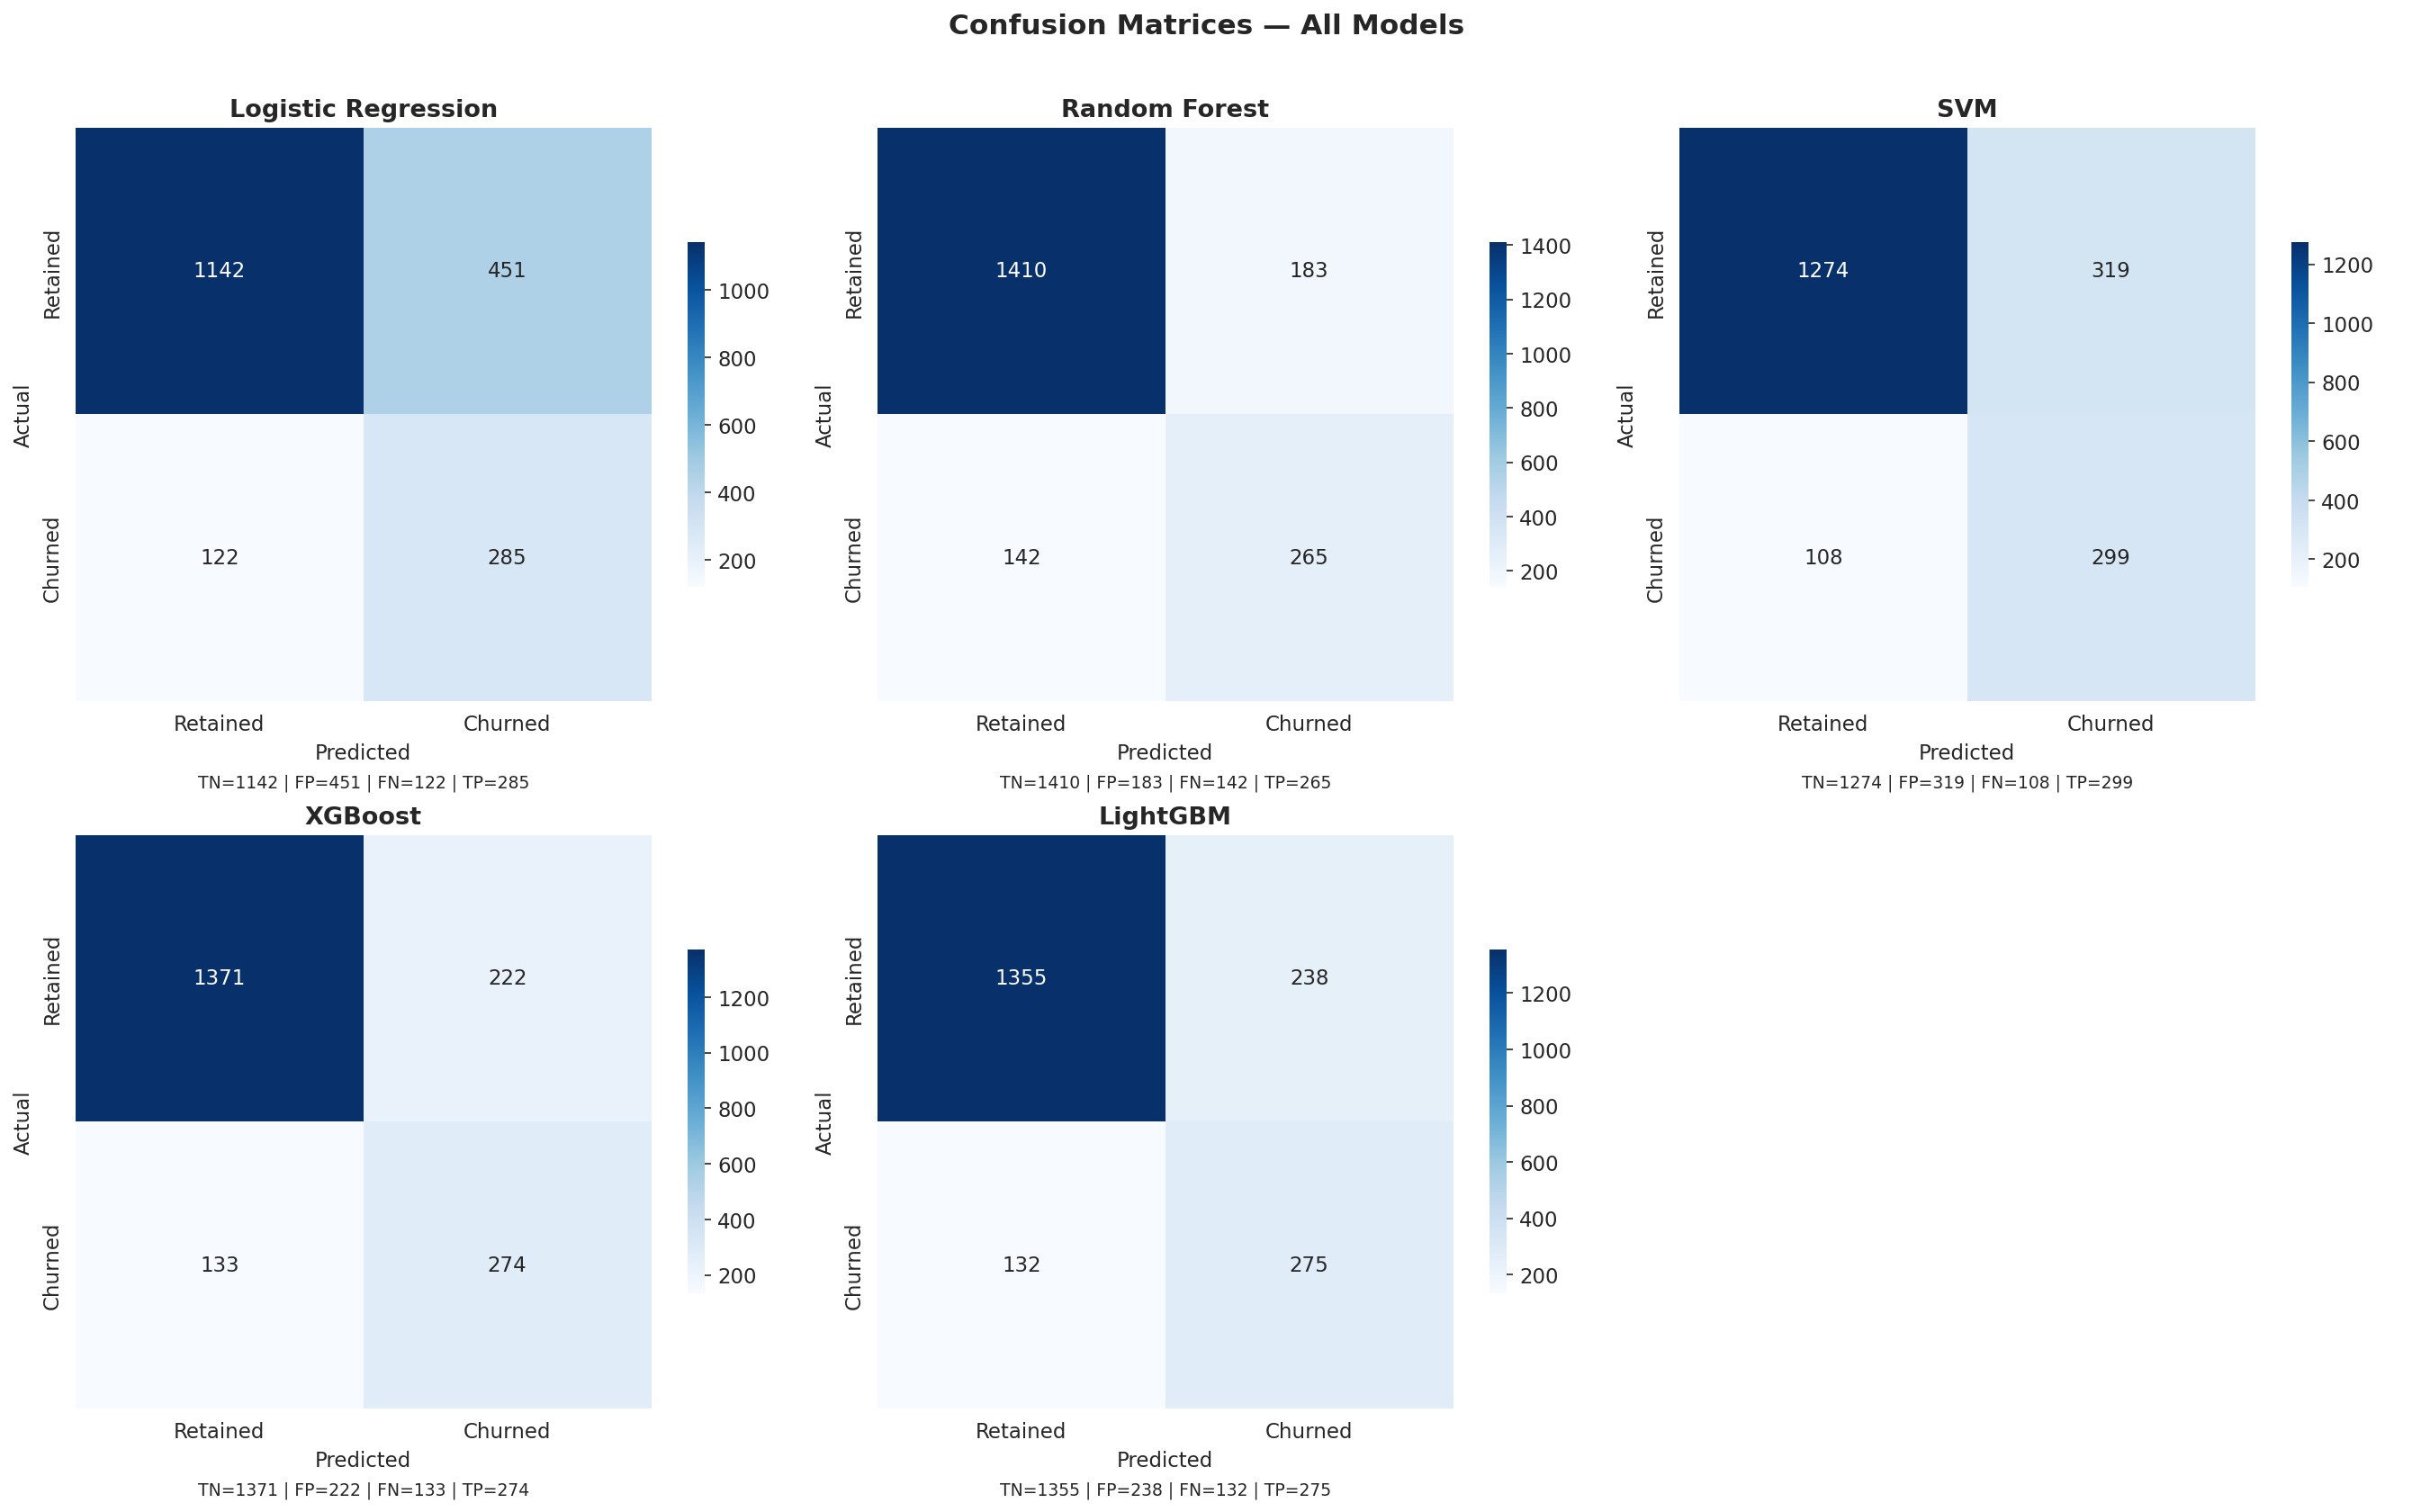

[Figure saved: fig8_confusion_matrices.png]


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                cbar_kws={'shrink': 0.6})
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

    tn, fp, fn, tp = cm.ravel()
    axes[idx].text(0.5, -0.15,
                   f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
                   transform=axes[idx].transAxes, ha='center', fontsize=9)

axes[-1].axis('off')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig8_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig8_confusion_matrices.png]")

### 7.4 ROC Curves

The ROC curve plots the true positive rate against the false positive rate at various classification thresholds. A higher AUC indicates better discriminative ability.

*Dissertation Note (Results):* Overlay all ROC curves on a single plot and report AUC values in the legend. Discuss which models demonstrate superior discrimination.

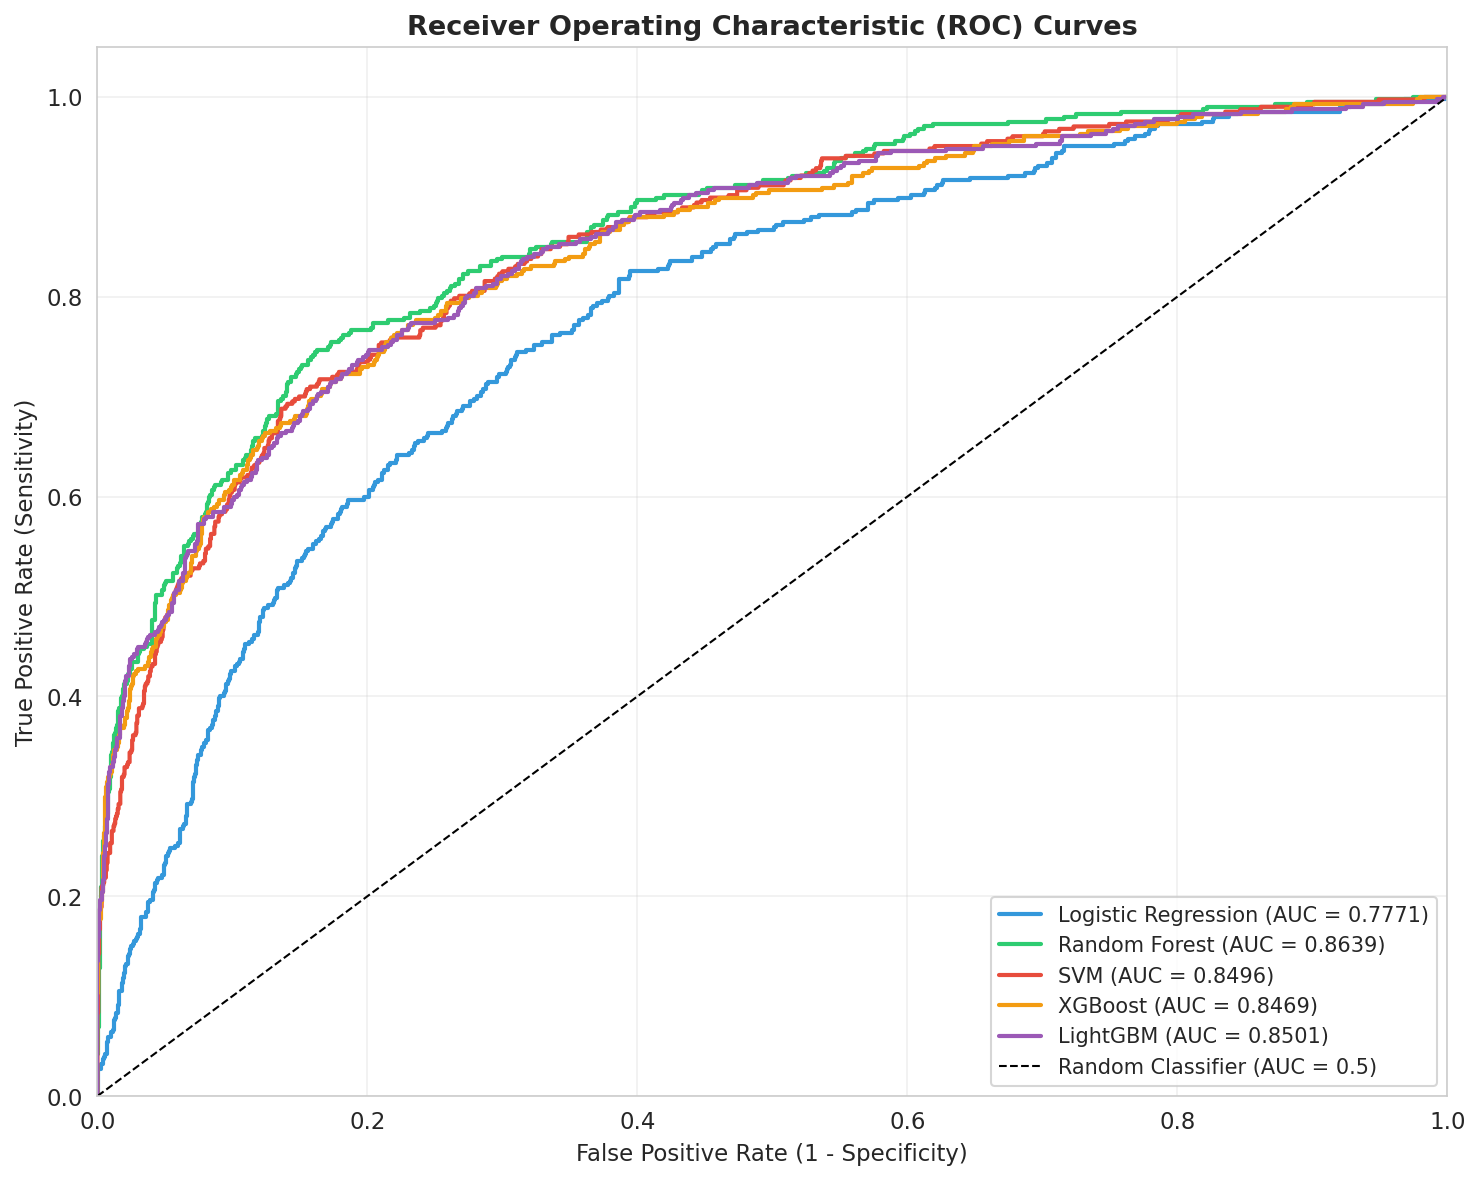

[Figure saved: fig9_roc_curves.png]


In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for (name, model), color in zip(trained_models.items(), colors_roc):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('Receiver Operating Characteristic (ROC) Curves', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig9_roc_curves.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig9_roc_curves.png]")

### 7.5 Detailed Classification Reports

In [19]:
print("="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

DETAILED CLASSIFICATION REPORTS

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.91      0.89      0.90      1593
     Churned       0.59      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.84      0.84      2000




──────────────────────────────────────────────────
  SVM
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.92      0.80      0.86      1593
     Churned       0.48      0.73      0.58       407

    accuracy                           0.79      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.83      0.79      0.80      2000


──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.91      0.86      0.89      1593
     Churned       0.55      0.67      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000


──────────────────────────────────────────────────
  LightGBM
──────────────────────────────────────────────────
          

---
## 8. Feature Importance Analysis

Tree-based models provide built-in feature importance scores. This section compares importance rankings across Random Forest, XGBoost, and LightGBM.

*Dissertation Note (Results):* Discuss which features consistently appear as top predictors across multiple models. This strengthens the argument for their relevance.

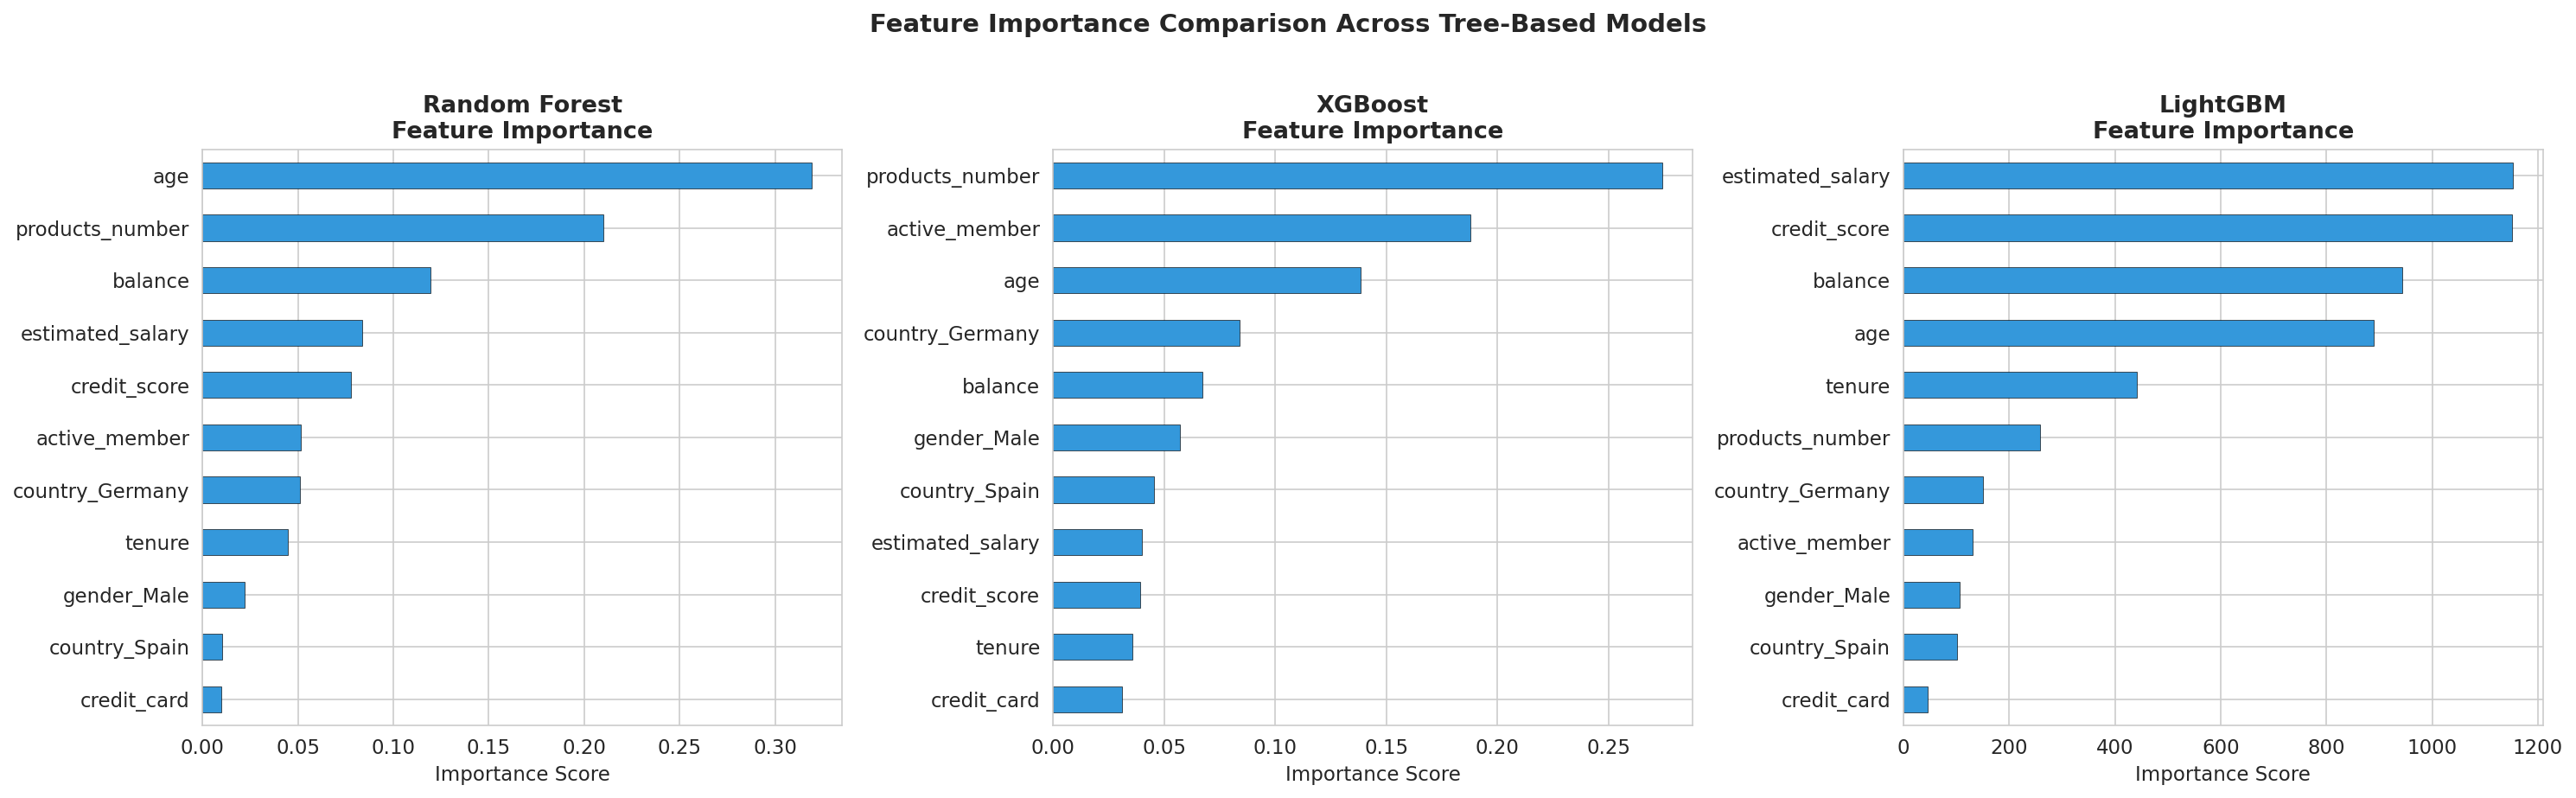

[Figure saved: fig10_feature_importance.png]


In [20]:
tree_models = {
    'Random Forest': trained_models['Random Forest'],
    'XGBoost': trained_models['XGBoost'],
    'LightGBM': trained_models['LightGBM']
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    feat_imp.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black', linewidth=0.3)
    ax.set_title(f'{name}\nFeature Importance', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison Across Tree-Based Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig10_feature_importance.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig10_feature_importance.png]")

---
## 9. Explainable AI — SHAP Analysis

SHAP (SHapley Additive exPlanations) provides a unified approach to interpreting machine learning predictions. Based on cooperative game theory, SHAP assigns each feature an importance value for a particular prediction.

**Key advantages of SHAP:**
- Provides both global and local explanations
- Theoretically grounded in Shapley values
- Model-agnostic (applicable to any model)
- Satisfies desirable properties: local accuracy, missingness, and consistency

*Dissertation Note (Methodology):* Explain SHAP theory, cite Lundberg and Lee (2017), and justify its selection over alternatives such as LIME. In the Results chapter, interpret SHAP summary plots and individual force plots.

*Ethical Considerations:* SHAP enhances transparency by revealing which features drive predictions, enabling stakeholders to verify that models do not rely on discriminatory attributes. This aligns with responsible AI principles and regulatory requirements such as the EU AI Act.

### 9.1 SHAP Analysis — Random Forest

Computing SHAP values for Random Forest...
(This may take a minute for large datasets)



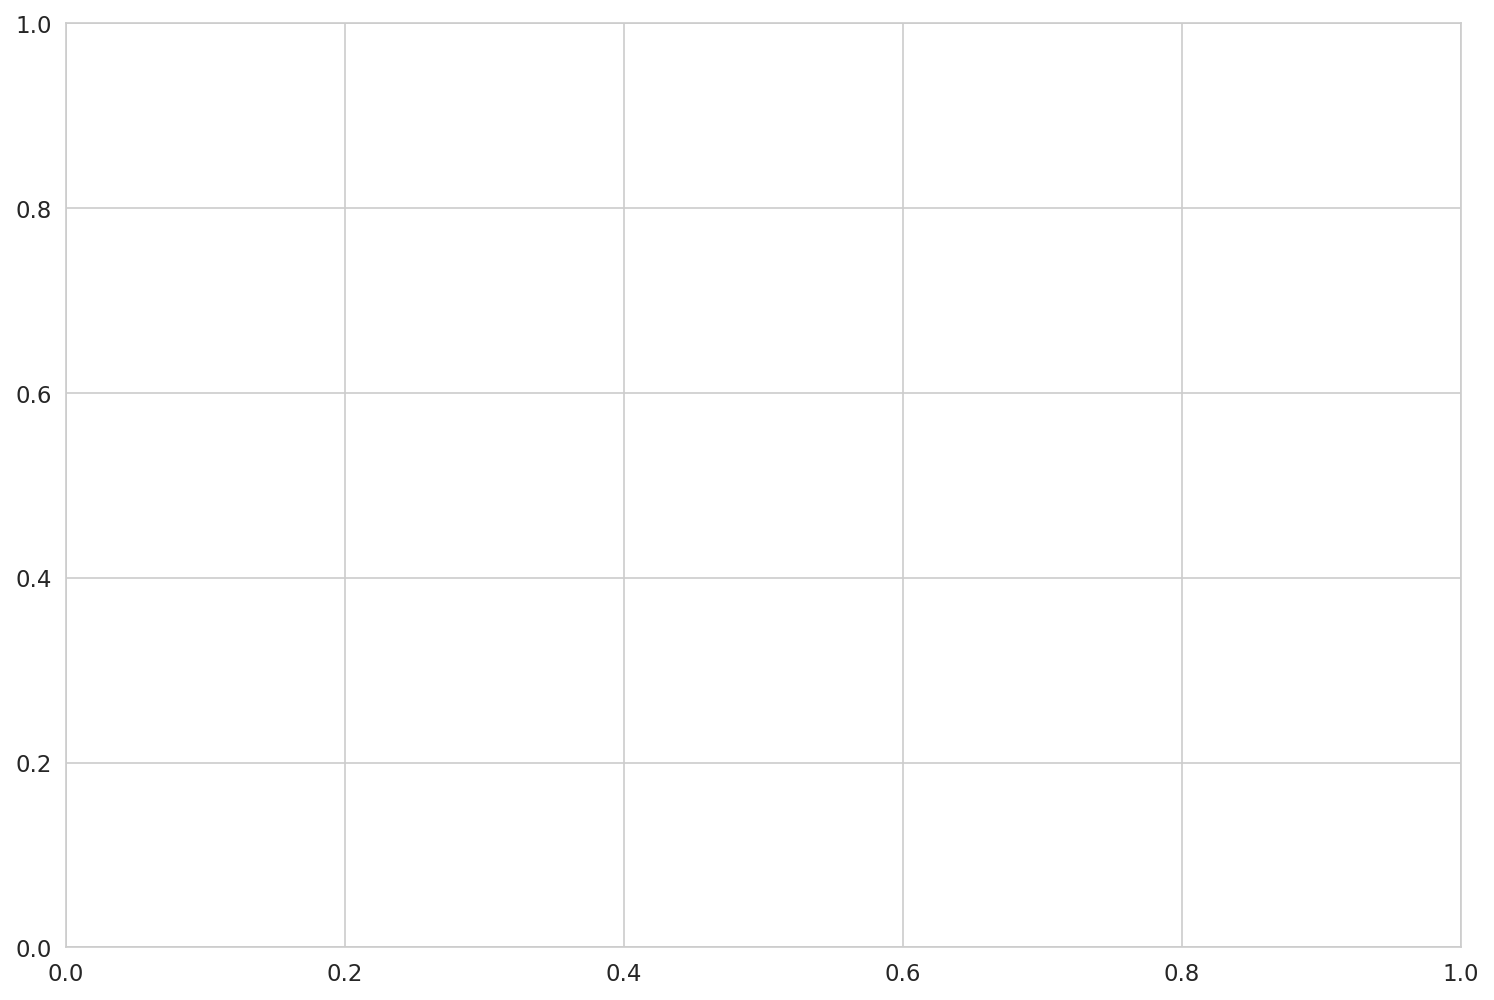

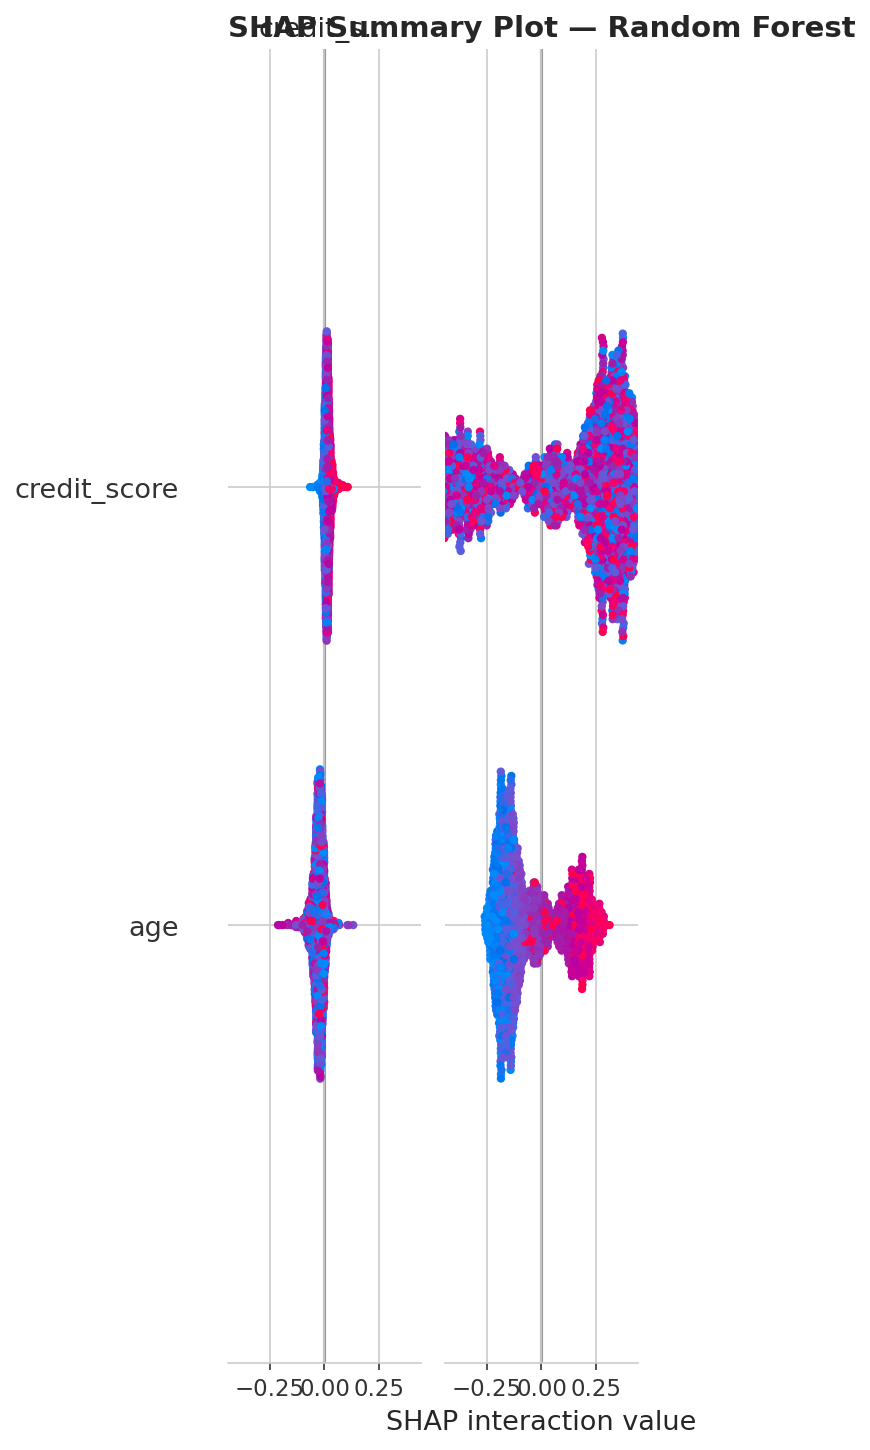

[Figure saved: fig11_shap_rf_summary.png]


In [21]:
print("Computing SHAP values for Random Forest...")
print("(This may take a minute for large datasets)\n")

rf_explainer = shap.TreeExplainer(trained_models['Random Forest'])
rf_shap_values = rf_explainer.shap_values(X_test)

if isinstance(rf_shap_values, list):
    rf_shap_vals = rf_shap_values[1]
else:
    rf_shap_vals = rf_shap_values

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(rf_shap_vals, X_test, feature_names=X.columns.tolist(),
                  show=False, max_display=12)
plt.title('SHAP Summary Plot — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig11_shap_rf_summary.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig11_shap_rf_summary.png]")

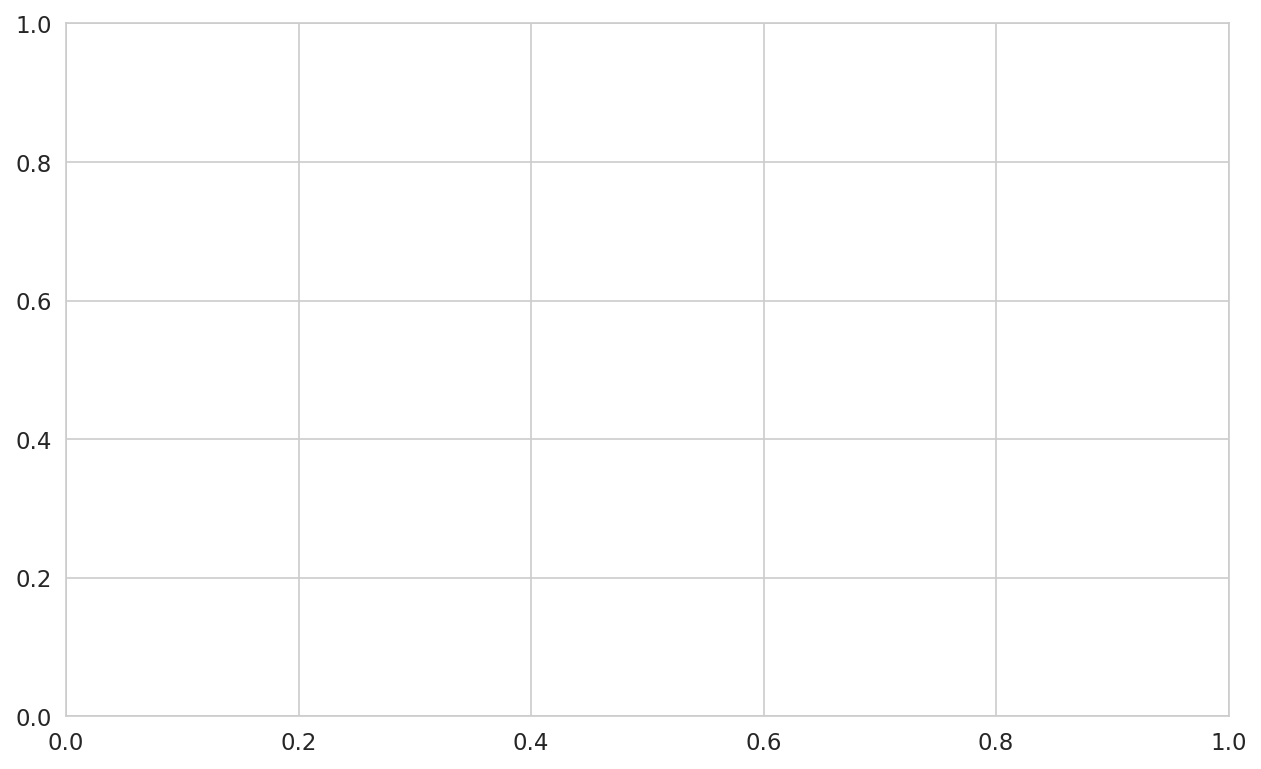

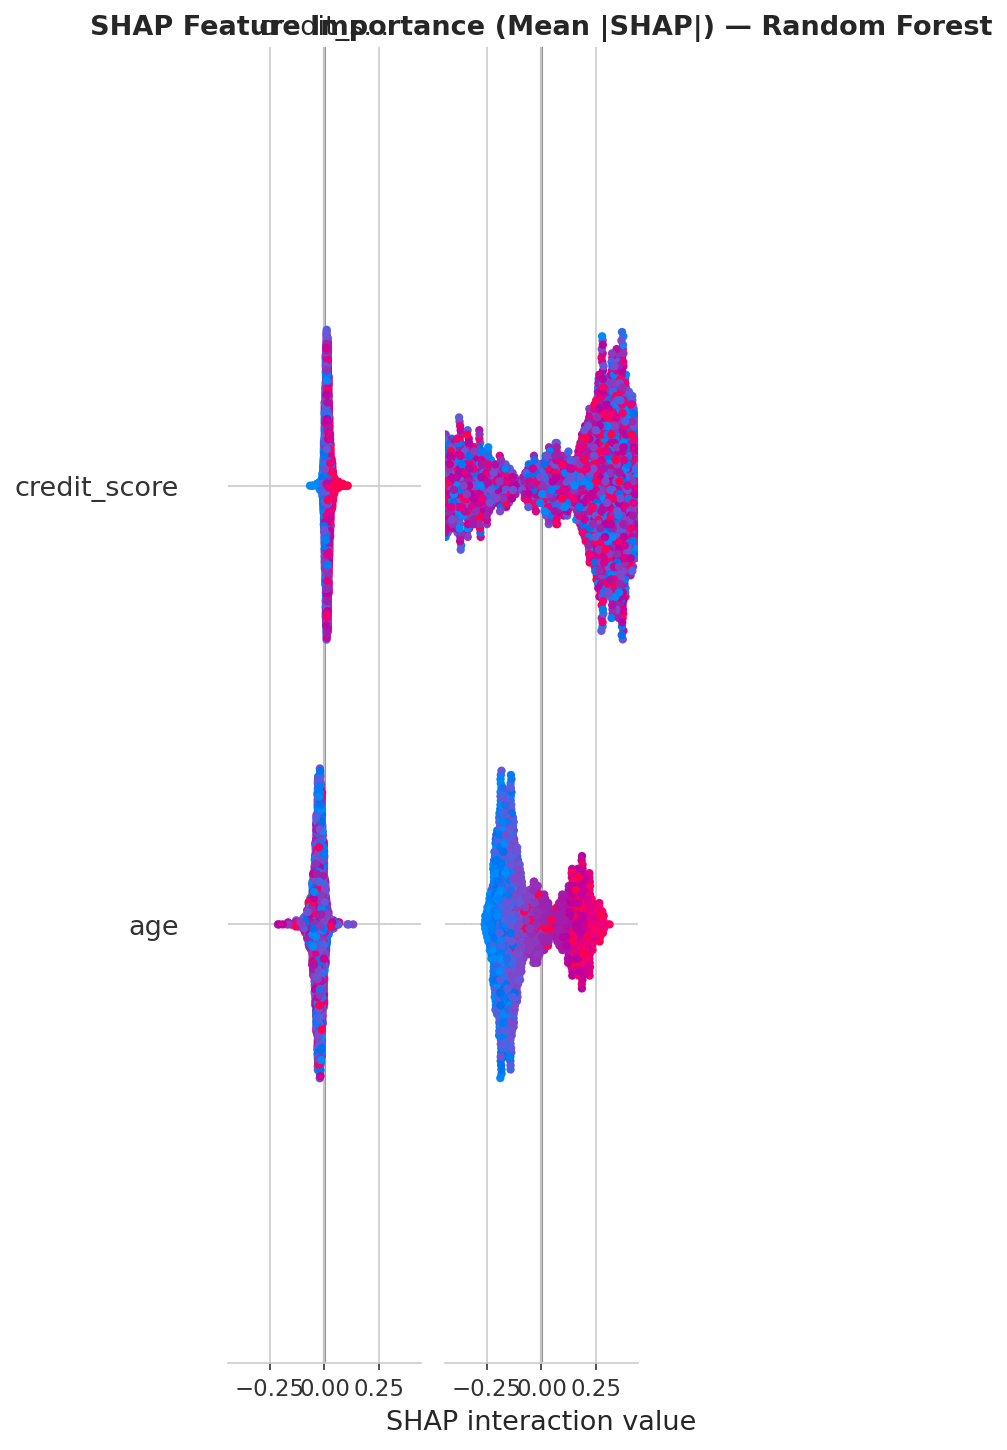

[Figure saved: fig12_shap_rf_bar.png]


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(rf_shap_vals, X_test, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False, max_display=12)
plt.title('SHAP Feature Importance (Mean |SHAP|) — Random Forest',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig12_shap_rf_bar.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig12_shap_rf_bar.png]")

### 9.2 SHAP Analysis — XGBoost

Computing SHAP values for XGBoost...


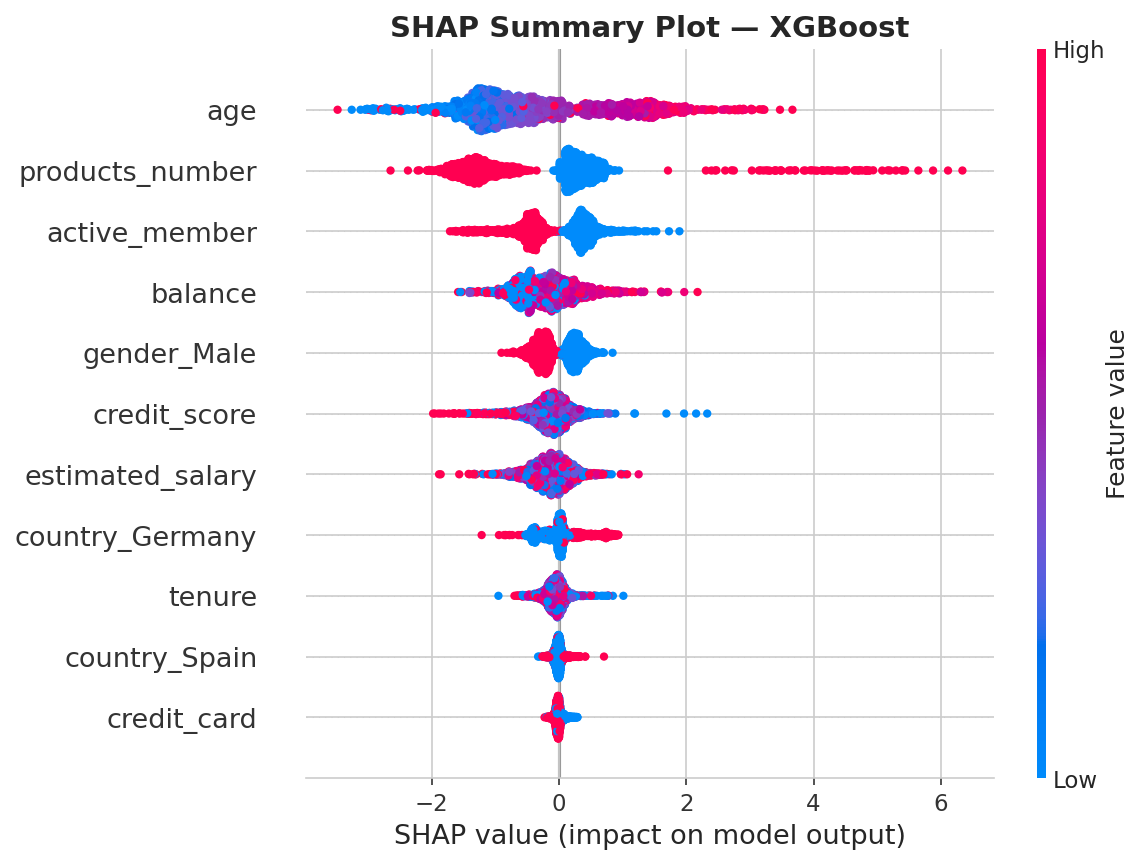

[Figure saved: fig13_shap_xgb_summary.png]


In [23]:
print("Computing SHAP values for XGBoost...")

xgb_explainer = shap.TreeExplainer(trained_models['XGBoost'])
xgb_shap_values = xgb_explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(xgb_shap_values, X_test, feature_names=X.columns.tolist(),
                  show=False, max_display=12)
plt.title('SHAP Summary Plot — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig13_shap_xgb_summary.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig13_shap_xgb_summary.png]")

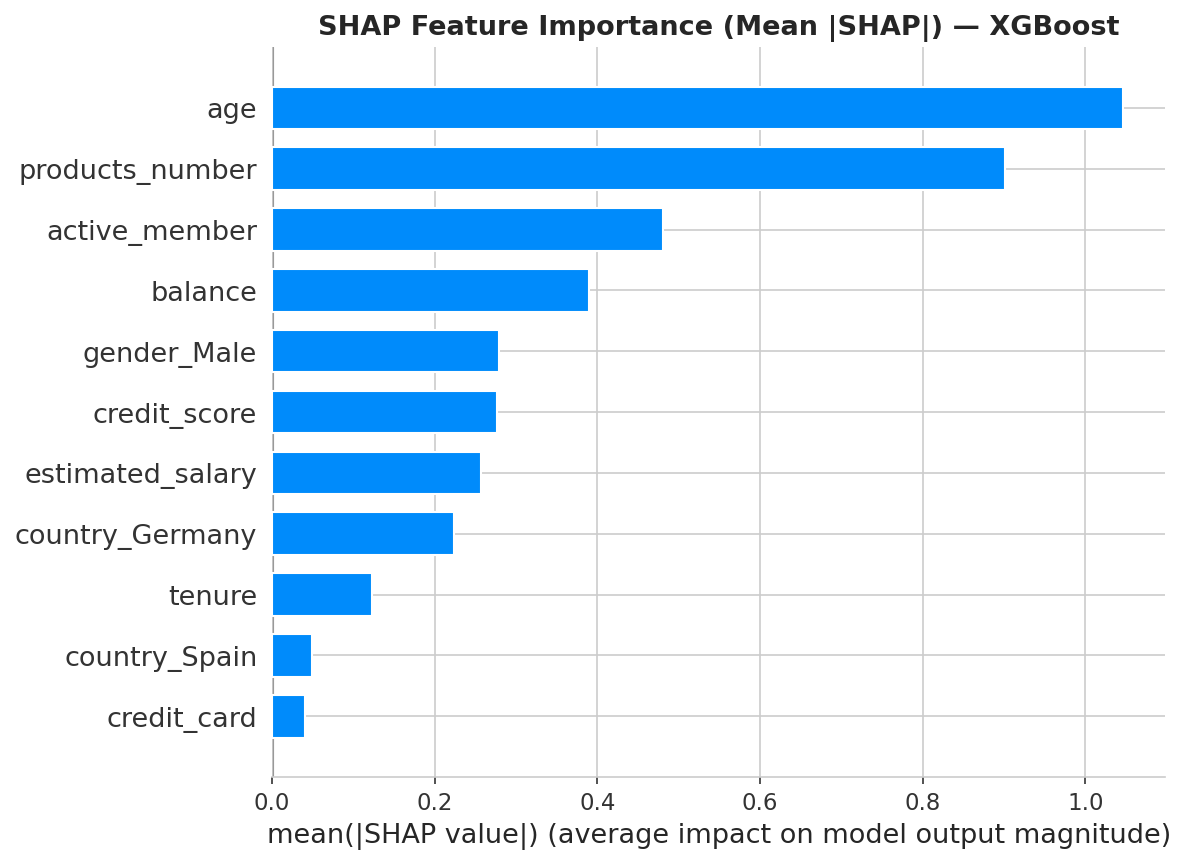

[Figure saved: fig14_shap_xgb_bar.png]


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(xgb_shap_values, X_test, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False, max_display=12)
plt.title('SHAP Feature Importance (Mean |SHAP|) — XGBoost',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig14_shap_xgb_bar.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig14_shap_xgb_bar.png]")

### 9.3 SHAP Analysis — LightGBM

Computing SHAP values for LightGBM...


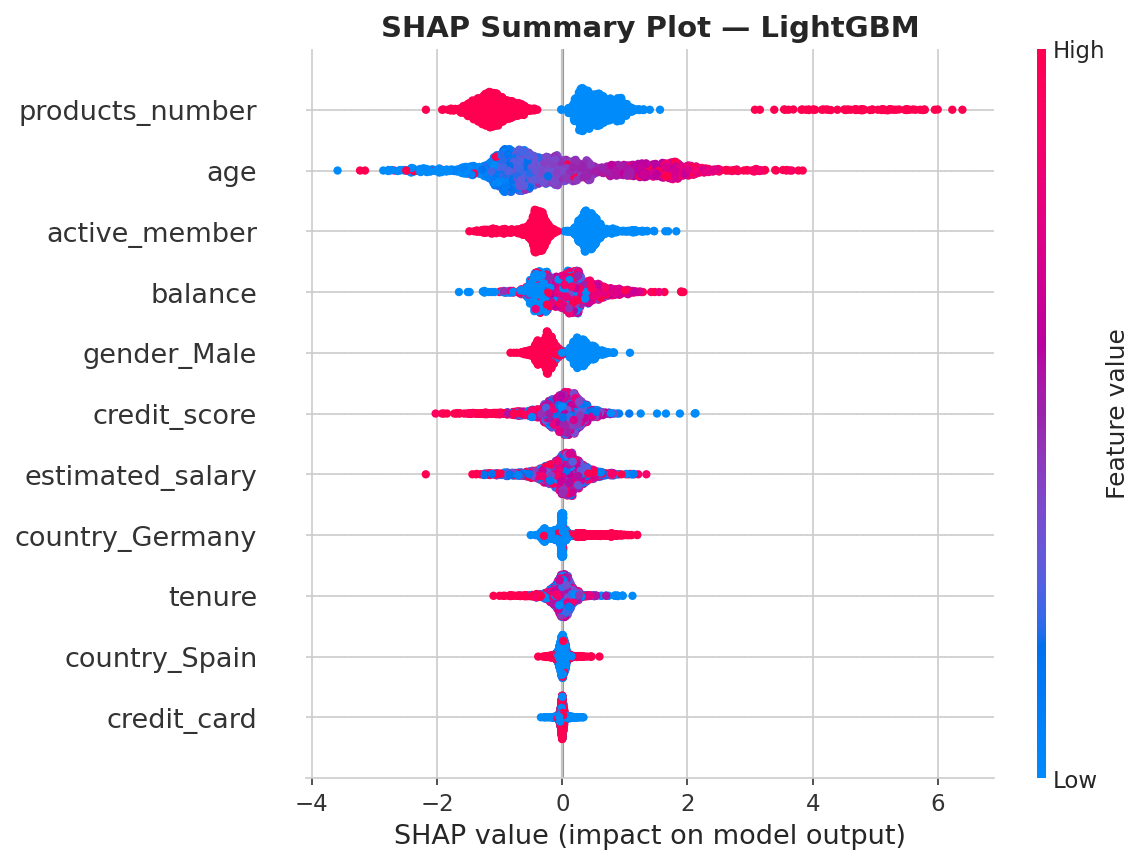

[Figure saved: fig15_shap_lgbm_summary.png]


In [25]:
print("Computing SHAP values for LightGBM...")

lgbm_explainer = shap.TreeExplainer(trained_models['LightGBM'])
lgbm_shap_values = lgbm_explainer.shap_values(X_test)

if isinstance(lgbm_shap_values, list):
    lgbm_shap_vals = lgbm_shap_values[1]
else:
    lgbm_shap_vals = lgbm_shap_values

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(lgbm_shap_vals, X_test, feature_names=X.columns.tolist(),
                  show=False, max_display=12)
plt.title('SHAP Summary Plot — LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig15_shap_lgbm_summary.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig15_shap_lgbm_summary.png]")

### 9.4 SHAP Dependence Plots

Dependence plots show how the SHAP value of a single feature varies with the feature's value, revealing non-linear relationships and interactions.

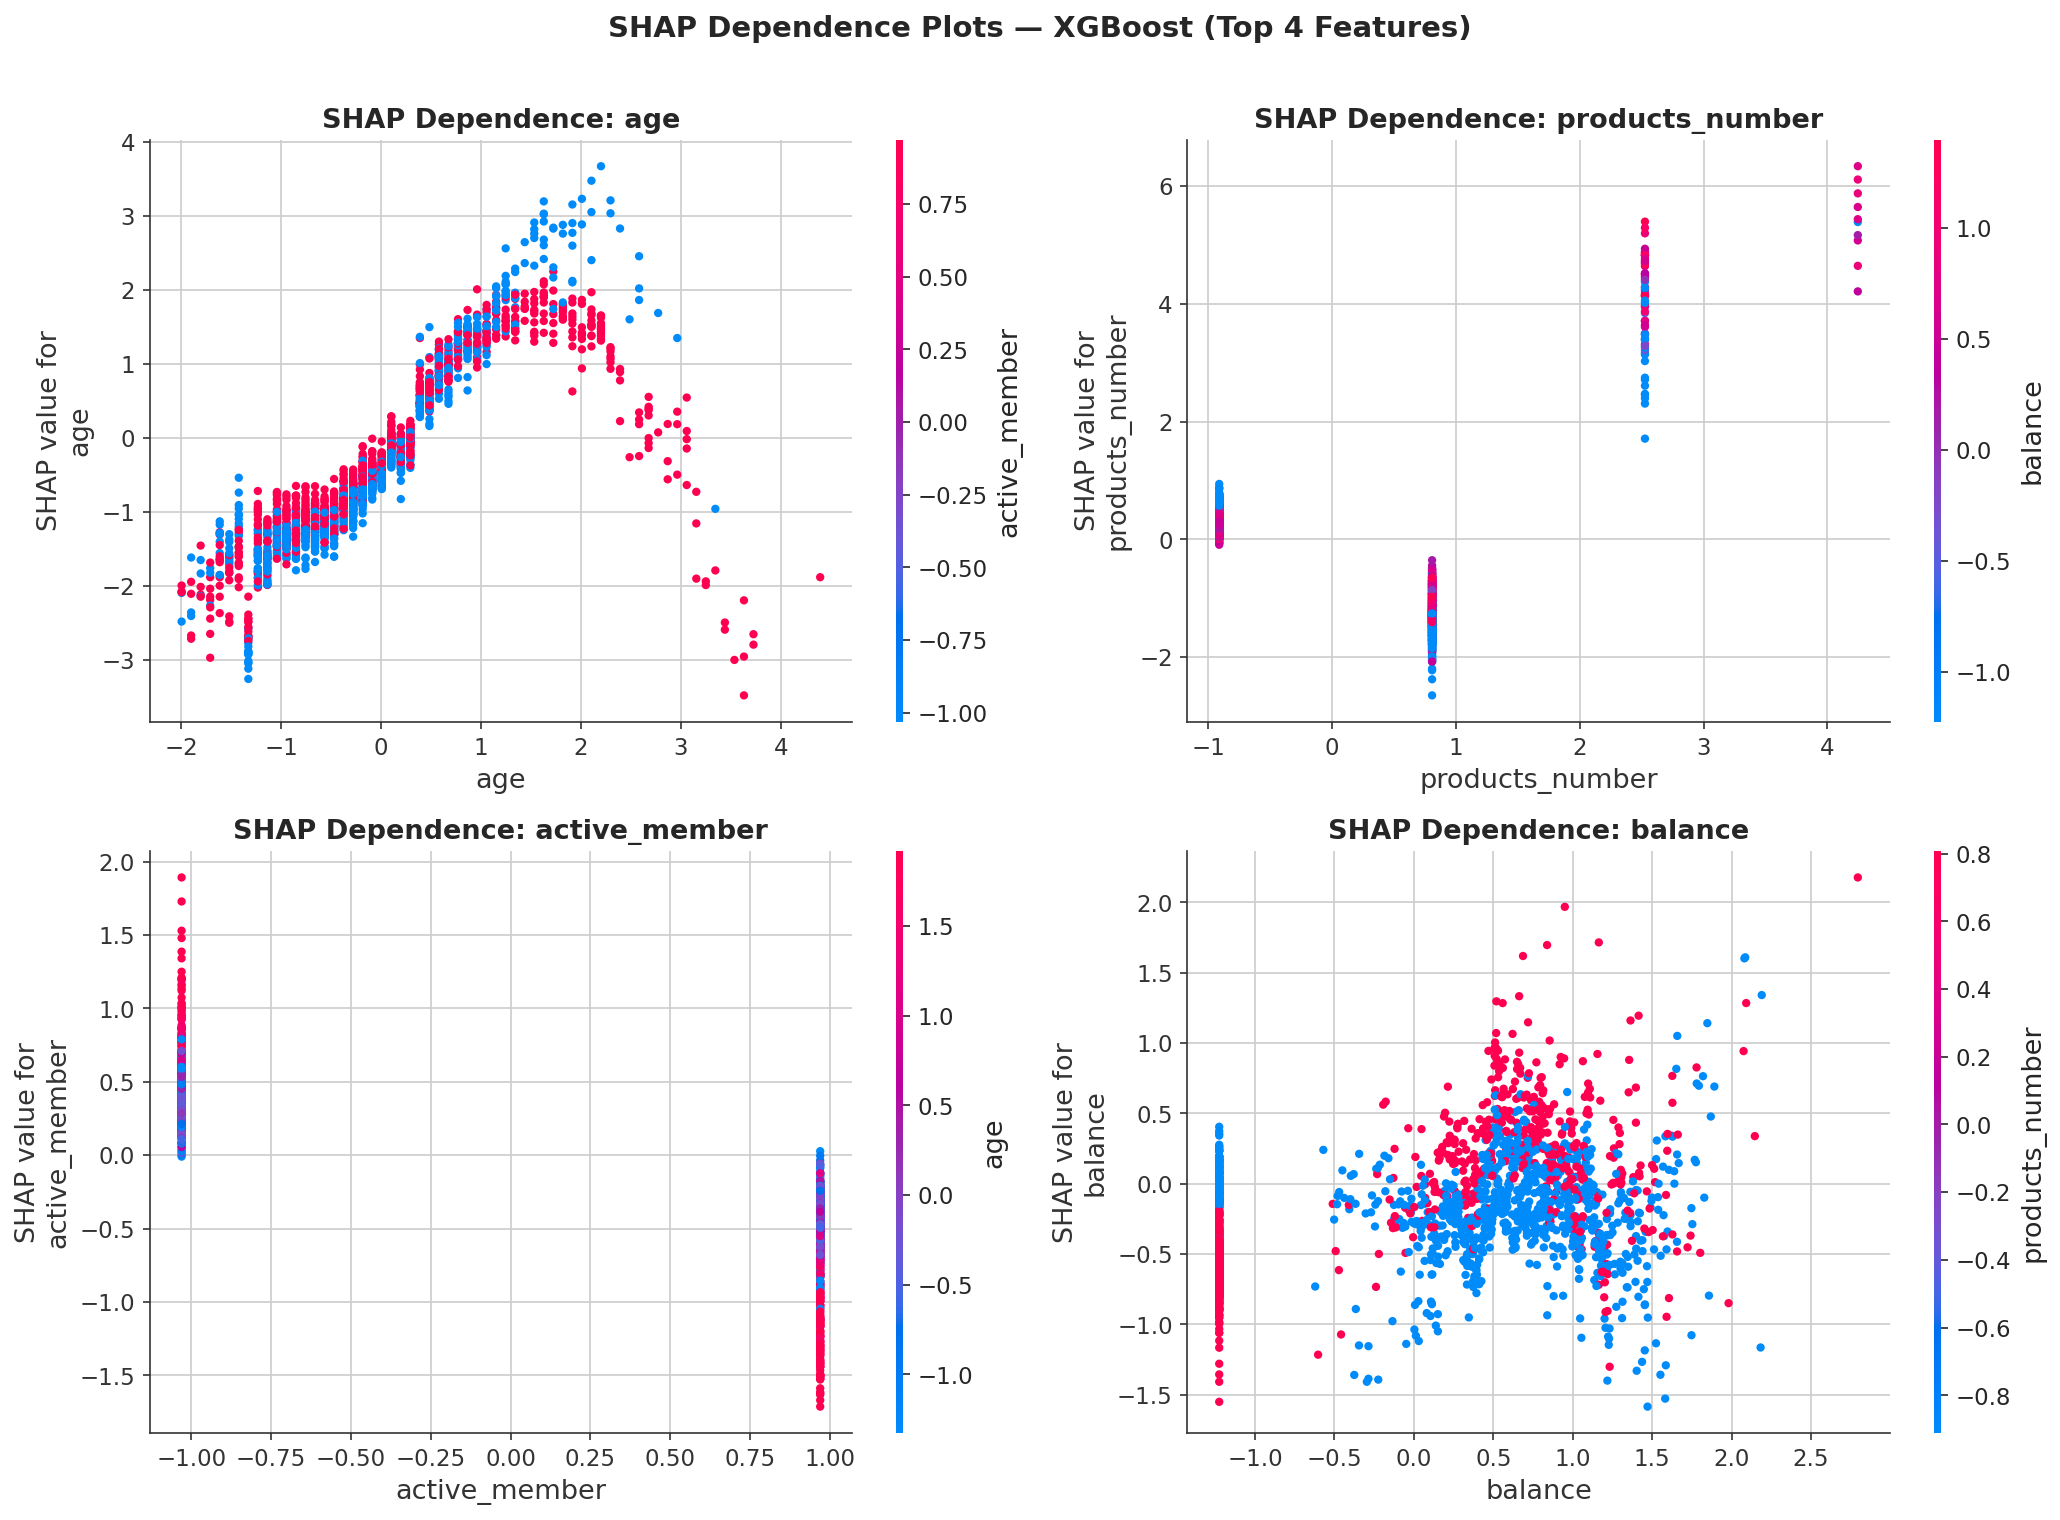

[Figure saved: fig16_shap_dependence.png]


In [26]:
top_features = pd.Series(np.abs(xgb_shap_values).mean(axis=0),
                         index=X.columns).nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax_idx, feat in enumerate(top_features):
    feat_idx = X.columns.tolist().index(feat)
    shap.dependence_plot(feat_idx, xgb_shap_values, X_test,
                         feature_names=X.columns.tolist(),
                         ax=axes[ax_idx], show=False)
    axes[ax_idx].set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — XGBoost (Top 4 Features)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig16_shap_dependence.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig16_shap_dependence.png]")

### 9.5 SHAP Force Plots — Individual Prediction Explanations

Force plots explain individual predictions, showing which features pushed the prediction towards churning or retention.

*Dissertation Note (Results):* Select representative examples — one correctly predicted churn and one correctly predicted retention — and interpret the contributing features.

In [27]:
shap.initjs()

y_pred_xgb = trained_models['XGBoost'].predict(X_test)

churned_correct = X_test[(y_test == 1) & (y_pred_xgb == 1)].index
retained_correct = X_test[(y_test == 0) & (y_pred_xgb == 0)].index

print("="*60)
print("INDIVIDUAL PREDICTION EXPLANATIONS (XGBoost)")
print("="*60)

if len(churned_correct) > 0:
    idx = churned_correct[0]
    local_idx = X_test.index.get_loc(idx)
    print(f"\n--- Example 1: Correctly Predicted CHURN (Index {idx}) ---")
    print(f"True label: Churned | Predicted: Churned")

    shap_vals = xgb_shap_values[local_idx]
    feature_contributions = pd.Series(shap_vals, index=X.columns).sort_values(key=abs, ascending=False)
    print(f"\nTop contributing features:")
    for feat, val in feature_contributions.head(5).items():
        direction = "↑ churn" if val > 0 else "↓ retention"
        print(f"  {feat:25s}: {val:+.4f} ({direction})")

if len(retained_correct) > 0:
    idx = retained_correct[0]
    local_idx = X_test.index.get_loc(idx)
    print(f"\n--- Example 2: Correctly Predicted RETENTION (Index {idx}) ---")
    print(f"True label: Retained | Predicted: Retained")

    shap_vals = xgb_shap_values[local_idx]
    feature_contributions = pd.Series(shap_vals, index=X.columns).sort_values(key=abs, ascending=False)
    print(f"\nTop contributing features:")
    for feat, val in feature_contributions.head(5).items():
        direction = "↑ churn" if val > 0 else "↓ retention"
        print(f"  {feat:25s}: {val:+.4f} ({direction})")

INDIVIDUAL PREDICTION EXPLANATIONS (XGBoost)

--- Example 1: Correctly Predicted CHURN (Index 7068) ---
True label: Churned | Predicted: Churned

Top contributing features:
  age                      : +1.9459 (↑ churn)
  active_member            : -0.7225 (↓ retention)
  credit_score             : -0.6307 (↓ retention)
  country_Germany          : +0.5755 (↑ churn)
  gender_Male              : +0.3629 (↑ churn)

--- Example 2: Correctly Predicted RETENTION (Index 5702) ---
True label: Retained | Predicted: Retained

Top contributing features:
  products_number          : -1.4642 (↓ retention)
  age                      : -0.7995 (↓ retention)
  active_member            : +0.5200 (↑ churn)
  balance                  : -0.5104 (↓ retention)
  gender_Male              : -0.3875 (↓ retention)


### 9.6 SHAP Waterfall Plots

Waterfall plots provide a detailed breakdown of how each feature contributes to an individual prediction, starting from the base value (expected output) and arriving at the final prediction.

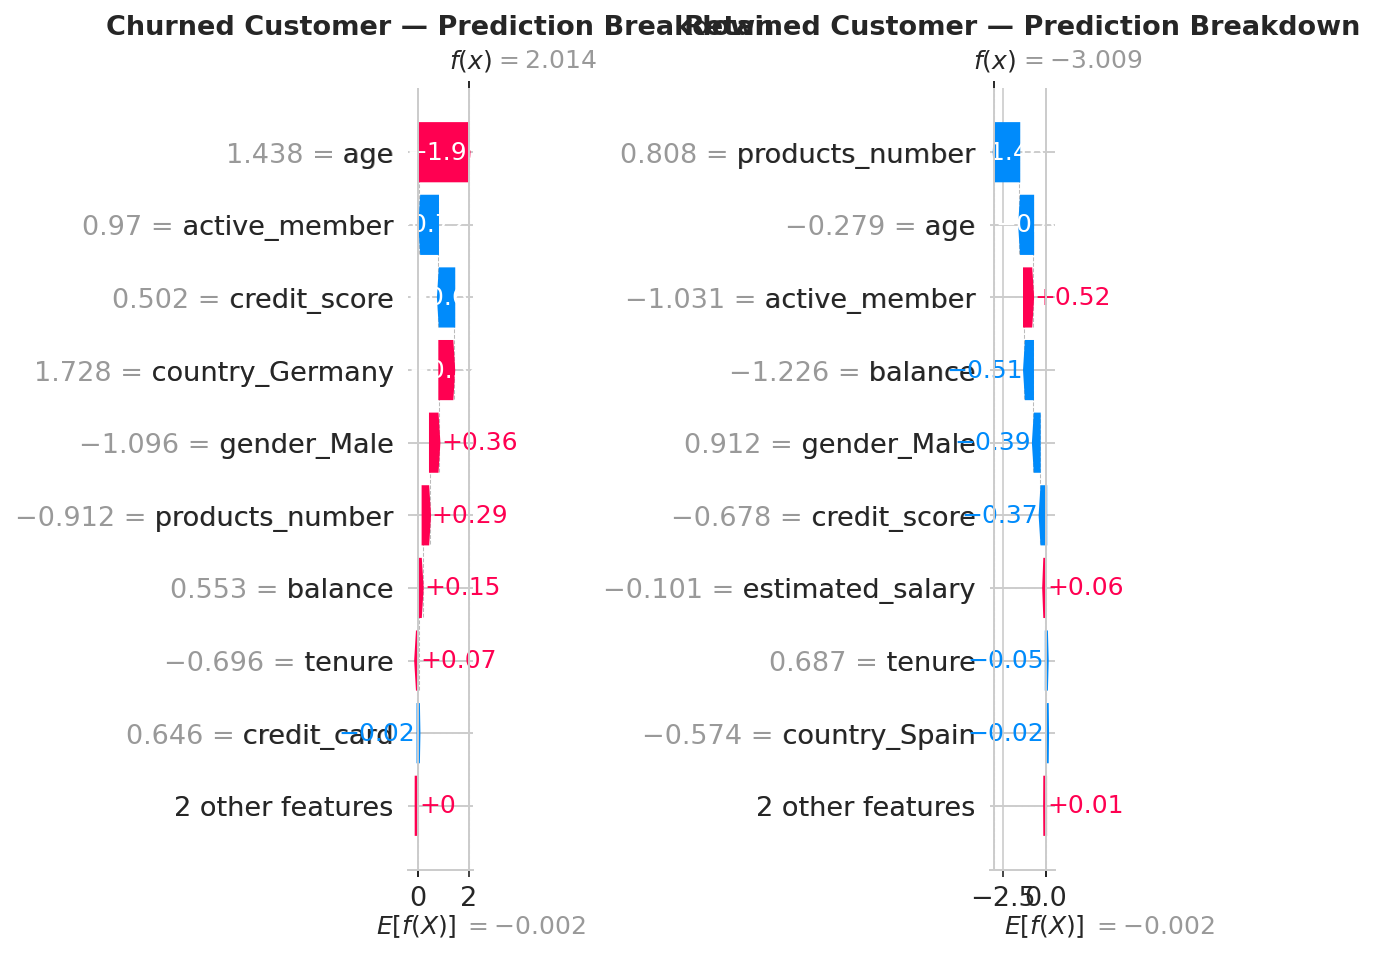

[Figure saved: fig17_shap_waterfall.png]


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if len(churned_correct) > 0:
    idx = churned_correct[0]
    local_idx = X_test.index.get_loc(idx)
    plt.sca(axes[0])
    expected_value = xgb_explainer.expected_value
    if isinstance(expected_value, np.ndarray):
        expected_value = expected_value[0]
    explanation = shap.Explanation(
        values=xgb_shap_values[local_idx],
        base_values=expected_value,
        data=X_test.iloc[local_idx].values,
        feature_names=X.columns.tolist()
    )
    shap.plots.waterfall(explanation, show=False, max_display=10)
    axes[0].set_title('Churned Customer — Prediction Breakdown', fontweight='bold')

if len(retained_correct) > 0:
    idx = retained_correct[0]
    local_idx = X_test.index.get_loc(idx)
    plt.sca(axes[1])
    explanation = shap.Explanation(
        values=xgb_shap_values[local_idx],
        base_values=expected_value,
        data=X_test.iloc[local_idx].values,
        feature_names=X.columns.tolist()
    )
    shap.plots.waterfall(explanation, show=False, max_display=10)
    axes[1].set_title('Retained Customer — Prediction Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig17_shap_waterfall.png', bbox_inches='tight')
plt.show()
print("[Figure saved: fig17_shap_waterfall.png]")

---
## 10. Summary and Key Findings

This section summarises the analysis outcomes and provides a consolidated view of the results.

In [29]:
print("="*70)
print("ANALYSIS SUMMARY")
print("="*70)

print("\n1. DATASET OVERVIEW")
print(f"   - {df.shape[0]} customers, {df.shape[1]} original features")
print(f"   - Churn rate: {(df['churn'].mean()*100):.1f}%")
print(f"   - No missing values")

print("\n2. KEY EDA FINDINGS")
print(f"   - Age: older customers show higher churn rates")
print(f"   - Geography: notable differences across countries")
print(f"   - Gender: female customers show higher churn tendency")
print(f"   - Products: customers with 3-4 products churn more frequently")

print("\n3. MODEL PERFORMANCE RANKING (by F1 Score)")
for i, (name, row) in enumerate(results_df.iterrows(), 1):
    print(f"   {i}. {name:25s} — F1: {row['F1 Score']:.4f} | AUC: {row['AUC-ROC']:.4f}")

best_model_name = results_df.index[0]
print(f"\n4. BEST MODEL: {best_model_name}")
print(f"   - Achieves highest F1 Score of {results_df.iloc[0]['F1 Score']:.4f}")
print(f"   - AUC-ROC: {results_df.iloc[0]['AUC-ROC']:.4f}")

print("\n5. XAI KEY INSIGHTS")
print("   - SHAP analysis reveals consistent top features across models")
print("   - Age, number of products, and activity status are strong predictors")
print("   - SHAP provides both global and local interpretability")
print("   - Individual predictions can be explained to stakeholders")

print("\n6. FIGURES GENERATED")
for f in sorted(os.listdir(FIGURE_DIR)):
    if f.endswith('.png'):
        print(f"   - {f}")

print(f"\n{'='*70}")
print("ANALYSIS COMPLETE")
print(f"{'='*70}")

ANALYSIS SUMMARY

1. DATASET OVERVIEW
   - 10000 customers, 12 original features
   - Churn rate: 20.4%
   - No missing values

2. KEY EDA FINDINGS
   - Age: older customers show higher churn rates
   - Geography: notable differences across countries
   - Gender: female customers show higher churn tendency
   - Products: customers with 3-4 products churn more frequently

3. MODEL PERFORMANCE RANKING (by F1 Score)
   1. Random Forest             — F1: 0.6199 | AUC: 0.8639
   2. XGBoost                   — F1: 0.6069 | AUC: 0.8469
   3. LightGBM                  — F1: 0.5978 | AUC: 0.8501
   4. SVM                       — F1: 0.5834 | AUC: 0.8496
   5. Logistic Regression       — F1: 0.4987 | AUC: 0.7771

4. BEST MODEL: Random Forest
   - Achieves highest F1 Score of 0.6199
   - AUC-ROC: 0.8639

5. XAI KEY INSIGHTS
   - SHAP analysis reveals consistent top features across models
   - Age, number of products, and activity status are strong predictors
   - SHAP provides both global and loc

---
## Figures Reference for Dissertation

| Figure | Description | Chapter |
|--------|------------|---------|
| fig1 | Churn distribution (bar + pie) | Results |
| fig2 | Feature distributions by churn | Results |
| fig3 | Categorical churn rates | Results |
| fig4 | Correlation heatmap | Results |
| fig5 | Box plots by churn status | Results |
| fig6 | Products vs churn rate | Results |
| fig7 | Model comparison bar chart | Results |
| fig8 | Confusion matrices | Results |
| fig9 | ROC curves | Results |
| fig10 | Feature importance (tree models) | Results |
| fig11 | SHAP summary (Random Forest) | Results / Discussion |
| fig12 | SHAP bar (Random Forest) | Results / Discussion |
| fig13 | SHAP summary (XGBoost) | Results / Discussion |
| fig14 | SHAP bar (XGBoost) | Results / Discussion |
| fig15 | SHAP summary (LightGBM) | Results / Discussion |
| fig16 | SHAP dependence plots | Results / Discussion |
| fig17 | SHAP waterfall plots | Results / Discussion |

All figures saved at 300 DPI in the `figures/` directory.